# Supplemental Code
Uijin Cho
ENVS 0070G

## Seoul Air Quality

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import pearsonr
from numpy import cov
import os

In [2]:
# Read in Seoul Air Quality

# Define the directory containing the CSV files
data_directory = './Data/Seoul_Air_Quality/'

# Get a list of all CSV files in the directory
csv_files = [f for f in os.listdir(data_directory) if f.endswith('.csv')]

# Initialize an empty list to store individual DataFrames
all_dfs = []

# Loop through each CSV file, read it, and append to the list
print(f"Found {len(csv_files)} CSV files. Reading and combining...")
for i, file in enumerate(csv_files):
    file_path = os.path.join(data_directory, file)
    try:
        df = pd.read_csv(file_path)
        all_dfs.append(df)
        if (i + 1) % 10 == 0: # Print progress every 10 files
            print(f"Processed {i + 1}/{len(csv_files)} files.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Concatenate all DataFrames into a single one
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print("All CSV files combined successfully!")
    print("Displaying the first 5 rows of the combined DataFrame:")
    display(combined_df.head())
    print("Shape of the combined DataFrame:", combined_df.shape)
else:
    print("No CSV files were found or successfully processed.")


Found 32 CSV files. Reading and combining...
Processed 10/32 files.
Processed 20/32 files.
Processed 30/32 files.
All CSV files combined successfully!
Displaying the first 5 rows of the combined DataFrame:


,측정일시,측정소 코드,측정항목,평균값,측정기 상태,국가 기준초과 구분,지자체 기준초과 구분
0,1988010100,103,1,0.120,0,0,0
1,1988010100,103,3,0.007,0,0,0
2,1988010100,103,5,10.300,0,0,0
3,1988010100,103,6,0.000,0,0,0
4,1988010100,103,8,-9999.000,4,0,0


Shape of the combined DataFrame: (34653851, 7)


In [3]:
# Rename useful columns
combined_df = combined_df.rename(columns={'측정일시': 'date-time', '측정소 코드': 'station', '측정항목': 'type', '평균값': 'measurement', '측정기 상태': 'state'})
display(combined_df)

,date-time,station,type,measurement,state,국가 기준초과 구분,지자체 기준초과 구분
0,1988010100,103,1,0.120,0,0,0
1,1988010100,103,3,0.007,0,0,0
2,1988010100,103,5,10.300,0,0,0
3,1988010100,103,6,0.000,0,0,0
4,1988010100,103,8,-9999.000,4,0,0
...,...,...,...,...,...,...,...
34653846,2022123123,125,3,0.054,0,0,0
34653847,2022123123,125,5,1.100,0,0,0
34653848,2022123123,125,6,0.002,0,0,0
34653849,2022123123,125,8,71.000,0,0,0


In [4]:
# Convert to Datetime
combined_df['date-time'] = pd.to_datetime(combined_df['date-time'], format='%Y%m%d%H')
display(combined_df)
combined_df.info()

,date-time,station,type,measurement,state,국가 기준초과 구분,지자체 기준초과 구분
0,1988-01-01 00:00:00,103,1,0.120,0,0,0
1,1988-01-01 00:00:00,103,3,0.007,0,0,0
2,1988-01-01 00:00:00,103,5,10.300,0,0,0
3,1988-01-01 00:00:00,103,6,0.000,0,0,0
4,1988-01-01 00:00:00,103,8,-9999.000,4,0,0
...,...,...,...,...,...,...,...
34653846,2022-12-31 23:00:00,125,3,0.054,0,0,0
34653847,2022-12-31 23:00:00,125,5,1.100,0,0,0
34653848,2022-12-31 23:00:00,125,6,0.002,0,0,0
34653849,2022-12-31 23:00:00,125,8,71.000,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34653851 entries, 0 to 34653850
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date-time    datetime64[ns]
 1   station      int64         
 2   type         int64         
 3   measurement  float64       
 4   state        int64         
 5   국가 기준초과 구분   int64         
 6   지자체 기준초과 구분  int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 1.8 GB


In [5]:
combined_df = combined_df.drop(columns=['국가 기준초과 구분', '지자체 기준초과 구분'])
display(combined_df)

,date-time,station,type,measurement,state
0,1988-01-01 00:00:00,103,1,0.120,0
1,1988-01-01 00:00:00,103,3,0.007,0
2,1988-01-01 00:00:00,103,5,10.300,0
3,1988-01-01 00:00:00,103,6,0.000,0
4,1988-01-01 00:00:00,103,8,-9999.000,4
...,...,...,...,...,...
34653846,2022-12-31 23:00:00,125,3,0.054,0
34653847,2022-12-31 23:00:00,125,5,1.100,0
34653848,2022-12-31 23:00:00,125,6,0.002,0
34653849,2022-12-31 23:00:00,125,8,71.000,0


In [6]:
# Drop non normal (0) state rows
cleaned_combined_df = combined_df.drop(combined_df[combined_df['state'] != 0].index)
display(cleaned_combined_df)

,date-time,station,type,measurement,state
0,1988-01-01 00:00:00,103,1,0.120,0
1,1988-01-01 00:00:00,103,3,0.007,0
2,1988-01-01 00:00:00,103,5,10.300,0
3,1988-01-01 00:00:00,103,6,0.000,0
6,1988-01-01 00:00:00,105,1,0.340,0
...,...,...,...,...,...
34653846,2022-12-31 23:00:00,125,3,0.054,0
34653847,2022-12-31 23:00:00,125,5,1.100,0
34653848,2022-12-31 23:00:00,125,6,0.002,0
34653849,2022-12-31 23:00:00,125,8,71.000,0


In [8]:
# separate to different dataframes by type
sulfurdioxide_df = cleaned_combined_df.loc[combined_df['type'] == 1]
carbonmonoxide_df = cleaned_combined_df.loc[combined_df['type'] == 3]
ozone_df = cleaned_combined_df.loc[combined_df['type'] == 5]
nitrogendioxide_df = cleaned_combined_df.loc[cleaned_combined_df['type'] == 6]
pm10_df = cleaned_combined_df.loc[cleaned_combined_df['type'] == 8]
pm25_df = cleaned_combined_df.loc[cleaned_combined_df['type'] == 9]

print("DataFrames created successfully:")
print(f"Sulfur Dioxide (type 1) DataFrame shape: {sulfurdioxide_df.shape}")
print(f"Carbon Monoxide (type 3) DataFrame shape: {carbonmonoxide_df.shape}")
print(f"Ozone (type 5) DataFrame shape: {ozone_df.shape}")
print(f"Nitrogen Dioxide (type 6) DataFrame shape: {nitrogendioxide_df.shape}")
print(f"PM10 (type 8) DataFrame shape: {pm10_df.shape}")
print(f"PM2.5 (type 9) DataFrame shape: {pm25_df.shape}")

display(sulfurdioxide_df)
display(carbonmonoxide_df)
display(ozone_df)
display(nitrogendioxide_df)
display(pm10_df)
display(pm25_df)

DataFrames created successfully:
Sulfur Dioxide (type 1) DataFrame shape: (5442852, 5)
Carbon Monoxide (type 3) DataFrame shape: (5433489, 5)
Ozone (type 5) DataFrame shape: (5398091, 5)
Nitrogen Dioxide (type 6) DataFrame shape: (5454701, 5)
PM10 (type 8) DataFrame shape: (4616774, 5)
PM2.5 (type 9) DataFrame shape: (3347625, 5)


,date-time,station,type,measurement,state
0,1988-01-01 00:00:00,103,1,0.120,0
6,1988-01-01 00:00:00,105,1,0.340,0
12,1988-01-01 00:00:00,107,1,0.399,0
18,1988-01-01 00:00:00,108,1,0.261,0
24,1988-01-01 00:00:00,113,1,0.443,0
...,...,...,...,...,...
34653821,2022-12-31 23:00:00,121,1,0.004,0
34653827,2022-12-31 23:00:00,122,1,0.003,0
34653833,2022-12-31 23:00:00,123,1,0.004,0
34653839,2022-12-31 23:00:00,124,1,0.003,0


,date-time,station,type,measurement,state
1,1988-01-01 00:00:00,103,3,0.007,0
7,1988-01-01 00:00:00,105,3,0.055,0
13,1988-01-01 00:00:00,107,3,0.046,0
19,1988-01-01 00:00:00,108,3,0.034,0
25,1988-01-01 00:00:00,113,3,0.039,0
...,...,...,...,...,...
34653822,2022-12-31 23:00:00,121,3,0.055,0
34653828,2022-12-31 23:00:00,122,3,0.052,0
34653834,2022-12-31 23:00:00,123,3,0.053,0
34653840,2022-12-31 23:00:00,124,3,0.051,0


,date-time,station,type,measurement,state
2,1988-01-01 00:00:00,103,5,10.3,0
8,1988-01-01 00:00:00,105,5,12.6,0
14,1988-01-01 00:00:00,107,5,13.4,0
20,1988-01-01 00:00:00,108,5,5.4,0
26,1988-01-01 00:00:00,113,5,14.6,0
...,...,...,...,...,...
34653823,2022-12-31 23:00:00,121,5,1.0,0
34653829,2022-12-31 23:00:00,122,5,0.8,0
34653835,2022-12-31 23:00:00,123,5,0.9,0
34653841,2022-12-31 23:00:00,124,5,0.9,0


,date-time,station,type,measurement,state
3,1988-01-01 00:00:00,103,6,0.000,0
9,1988-01-01 00:00:00,105,6,0.043,0
21,1988-01-01 00:00:00,108,6,0.000,0
27,1988-01-01 00:00:00,113,6,0.000,0
33,1988-01-01 00:00:00,117,6,0.000,0
...,...,...,...,...,...
34653824,2022-12-31 23:00:00,121,6,0.004,0
34653830,2022-12-31 23:00:00,122,6,0.003,0
34653836,2022-12-31 23:00:00,123,6,0.003,0
34653842,2022-12-31 23:00:00,124,6,0.002,0


,date-time,station,type,measurement,state
162094,1988-05-20 16:00:00,124,8,56.0,0
162142,1988-05-20 17:00:00,124,8,85.0,0
162190,1988-05-20 18:00:00,124,8,66.0,0
162238,1988-05-20 19:00:00,124,8,69.0,0
162286,1988-05-20 20:00:00,124,8,73.0,0
...,...,...,...,...,...
34653825,2022-12-31 23:00:00,121,8,57.0,0
34653831,2022-12-31 23:00:00,122,8,51.0,0
34653837,2022-12-31 23:00:00,123,8,49.0,0
34653843,2022-12-31 23:00:00,124,8,47.0,0


,date-time,station,type,measurement,state
8614206,2000-02-11 18:00:00,107,9,25.0,0
8614356,2000-02-11 19:00:00,107,9,41.0,0
8614506,2000-02-11 20:00:00,107,9,52.0,0
8614656,2000-02-11 21:00:00,107,9,62.0,0
8614806,2000-02-11 22:00:00,107,9,79.0,0
...,...,...,...,...,...
34653826,2022-12-31 23:00:00,121,9,37.0,0
34653832,2022-12-31 23:00:00,122,9,44.0,0
34653838,2022-12-31 23:00:00,123,9,36.0,0
34653844,2022-12-31 23:00:00,124,9,34.0,0


In [ ]:
# Drop type
sulfurdioxide_df = sulfurdioxide_df.drop(columns=['type'])
carbonmonoxide_df = carbonmonoxide_df.drop(columns=['type'])
ozone_df = ozone_df.drop(columns=['type'])
nitrogendioxide_df = nitrogendioxide_df.drop(columns=['type'])
pm10_df = pm10_df.drop(columns=['type'])
pm25_df = pm25_df.drop(columns=['type'])

In [10]:
# descriptive statistics for all
print("sulfurdioxide_df statistics:")
display(sulfurdioxide_df.describe())
print("carbonmonoxide_df statistics:")
display(carbonmonoxide_df.describe())
print("ozone_df statistics:")
display(ozone_df.describe())
print("nitrogendioxide_df statistics:")
display(nitrogendioxide_df.describe())
print("pm10_df statistics:")
display(pm10_df.describe())
print("pm25_df statistics:")
display(pm25_df.describe())


sulfurdioxide_df statistics:


,date-time,station,measurement,state
count,5442852,5.442852e+06,5.442852e+06,5442852.0
mean,2007-08-28 05:47:59.200610048,1.129580e+02,8.511325e-03,0.0
min,1988-01-01 00:00:00,1.010000e+02,0.000000e+00,0.0
25%,2000-07-29 08:00:00,1.070000e+02,3.000000e-03,0.0
50%,2007-04-04 04:00:00,1.130000e+02,5.000000e-03,0.0
75%,2014-08-25 01:00:00,1.190000e+02,8.000000e-03,0.0
max,2022-12-31 23:00:00,1.250000e+02,9.670000e-01,0.0
std,NaN,7.182505e+00,1.908886e-02,0.0


carbonmonoxide_df statistics:


,date-time,station,measurement,state
count,5433489,5.433489e+06,5.433489e+06,5433489.0
mean,2007-09-01 16:06:53.706993920,1.129316e+02,3.234080e-02,0.0
min,1988-01-01 00:00:00,1.010000e+02,0.000000e+00,0.0
25%,2000-08-04 07:00:00,1.070000e+02,1.800000e-02,0.0
50%,2007-04-17 20:00:00,1.130000e+02,2.900000e-02,0.0
75%,2014-09-02 14:00:00,1.190000e+02,4.300000e-02,0.0
max,2022-12-31 23:00:00,1.250000e+02,6.870000e-01,0.0
std,NaN,7.195027e+00,1.826488e-02,0.0


ozone_df statistics:


...

,date-time,station,measurement,state
count,5454701,5.454701e+06,5.454701e+06,5454701.0
mean,2007-08-21 04:35:28.374625536,1.129418e+02,1.912580e-02,0.0
min,1988-01-01 00:00:00,1.010000e+02,0.000000e+00,0.0
25%,2000-07-30 23:00:00,1.070000e+02,5.000000e-03,0.0
50%,2007-03-27 03:00:00,1.130000e+02,1.500000e-02,0.0
75%,2014-08-22 03:00:00,1.190000e+02,2.800000e-02,0.0
max,2022-12-31 23:00:00,1.250000e+02,2.950000e-01,0.0
std,NaN,7.192802e+00,1.776362e-02,0.0


pm10_df statistics:


,date-time,station,measurement,state
count,4616774,4.616774e+06,4.616774e+06,4616774.0
mean,2009-11-01 13:46:03.327464960,1.130994e+02,5.312183e+01,0.0
min,1988-05-20 16:00:00,1.010000e+02,0.000000e+00,0.0
25%,2003-07-25 10:00:00,1.070000e+02,2.600000e+01,0.0
50%,2009-02-28 06:00:00,1.130000e+02,4.200000e+01,0.0
75%,2017-07-28 09:00:00,1.190000e+02,6.700000e+01,0.0
max,2022-12-31 23:00:00,1.250000e+02,3.311000e+03,0.0
std,NaN,7.209879e+00,4.720864e+01,0.0


pm25_df statistics:


,date-time,station,measurement,state
count,3347625,3.347625e+06,3.347625e+06,3347625.0
mean,2013-04-04 04:47:40.911840768,1.131447e+02,2.540482e+01,0.0
min,2000-02-11 18:00:00,1.010000e+02,1.000000e+00,0.0
25%,2008-02-14 12:00:00,1.070000e+02,1.200000e+01,0.0
50%,2013-02-22 02:00:00,1.130000e+02,2.000000e+01,0.0
75%,2019-02-03 11:00:00,1.200000e+02,3.300000e+01,0.0
max,2022-12-31 23:00:00,1.250000e+02,1.145000e+03,0.0
std,NaN,7.203405e+00,2.024443e+01,0.0


In [12]:
# Average each measurement by day
averaged_sulfurdioxide_df = sulfurdioxide_df.set_index('date-time').resample('D')['measurement'].mean()
averaged_carbonmonoxide_df = carbonmonoxide_df.set_index('date-time').resample('D')['measurement'].mean()
averaged_ozone_df = ozone_df.set_index('date-time').resample('D')['measurement'].mean()
averaged_nitrogendioxide_df = nitrogendioxide_df.set_index('date-time').resample('D')['measurement'].mean()
averaged_pm10_df = pm10_df.set_index('date-time').resample('D')['measurement'].mean()
averaged_pm25_df = pm25_df.set_index('date-time').resample('D')['measurement'].mean()

### Displaying each of the pollutants individually

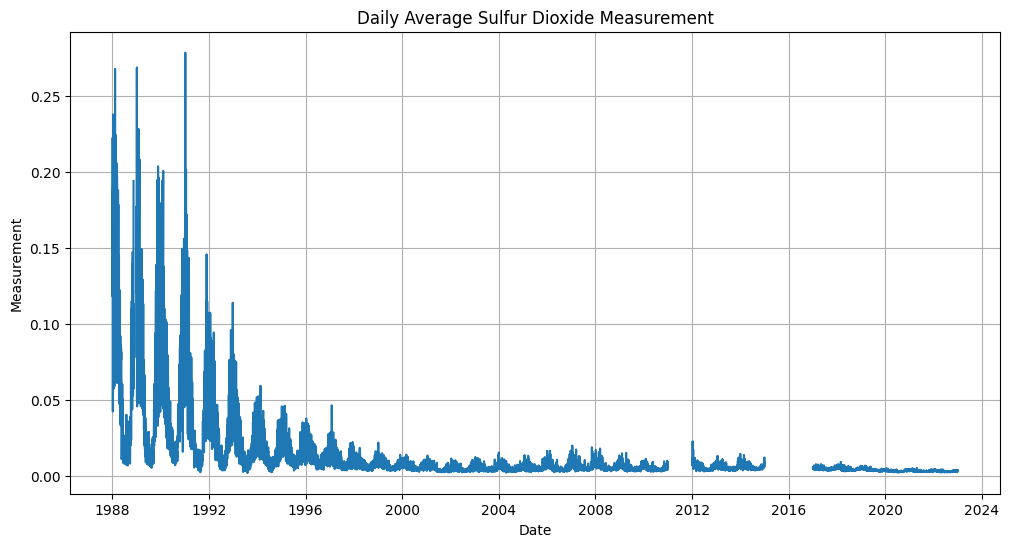

In [13]:
# Sulfur Dioxide Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_sulfurdioxide_df.index, averaged_sulfurdioxide_df.values)
plt.title('Daily Average Sulfur Dioxide Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

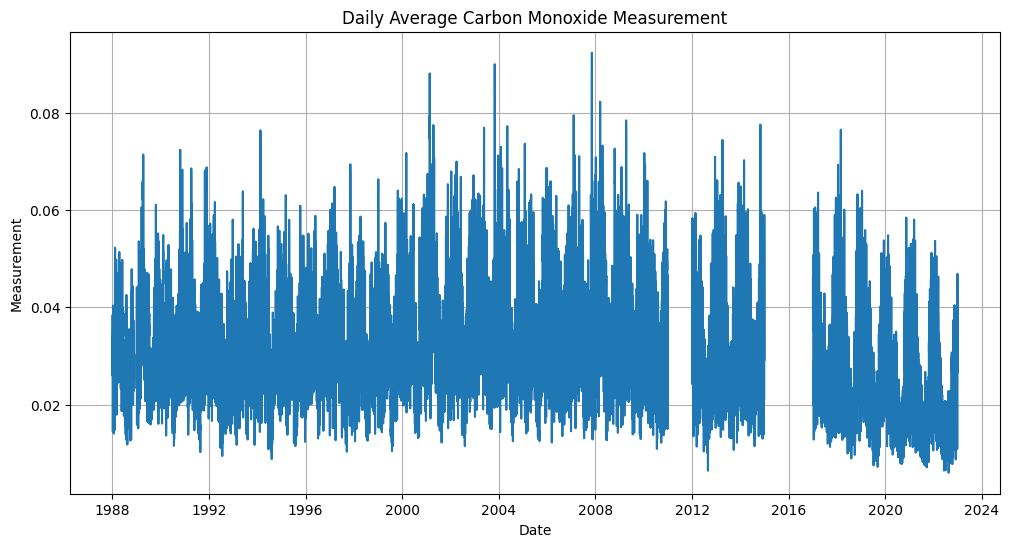

In [14]:
# Carbon Monoxide Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_carbonmonoxide_df.index, averaged_carbonmonoxide_df.values)
plt.title('Daily Average Carbon Monoxide Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

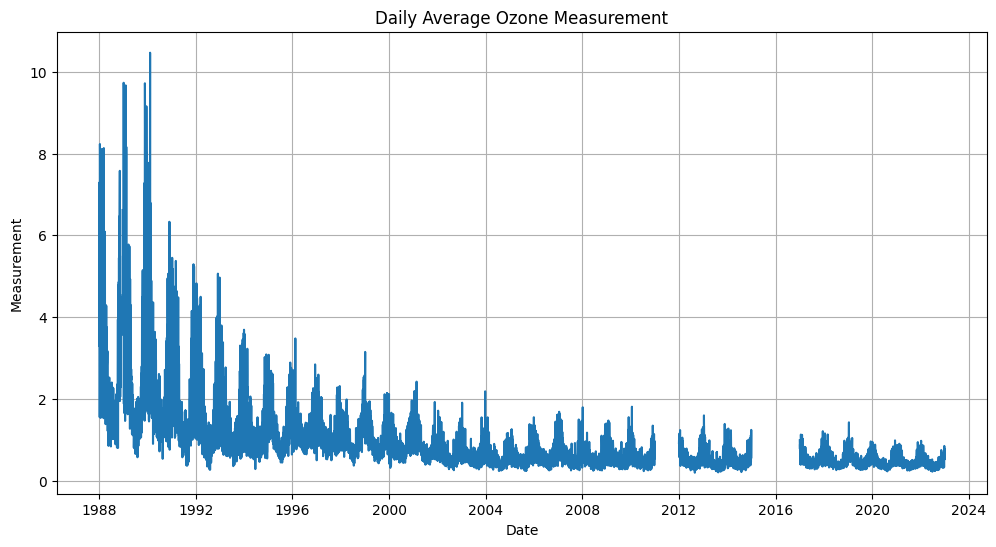

In [15]:
# Ozone Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_ozone_df.index, averaged_ozone_df.values)
plt.title('Daily Average Ozone Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

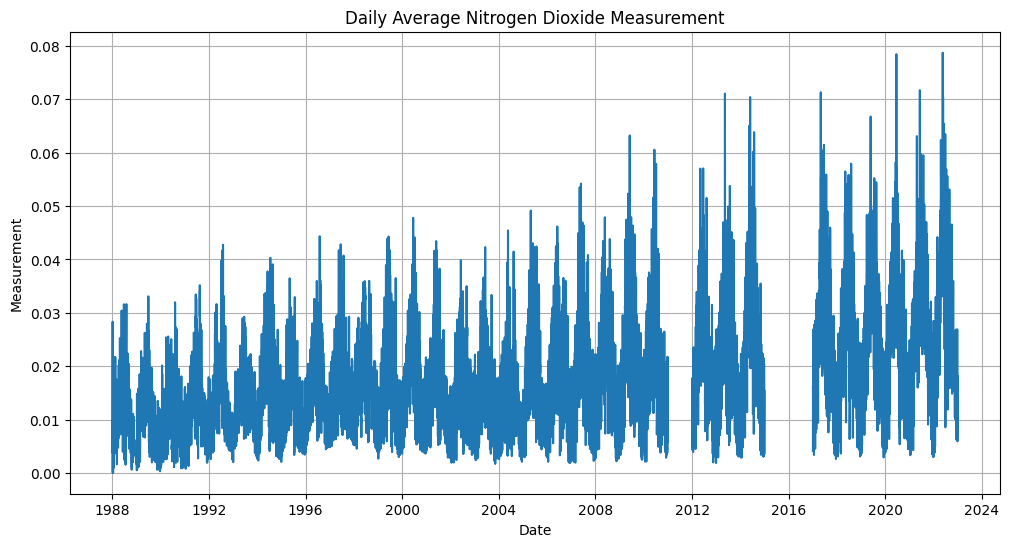

In [16]:
# Nitorgen Dioxide Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_nitrogendioxide_df.index, averaged_nitrogendioxide_df.values)
plt.title('Daily Average Nitrogen Dioxide Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

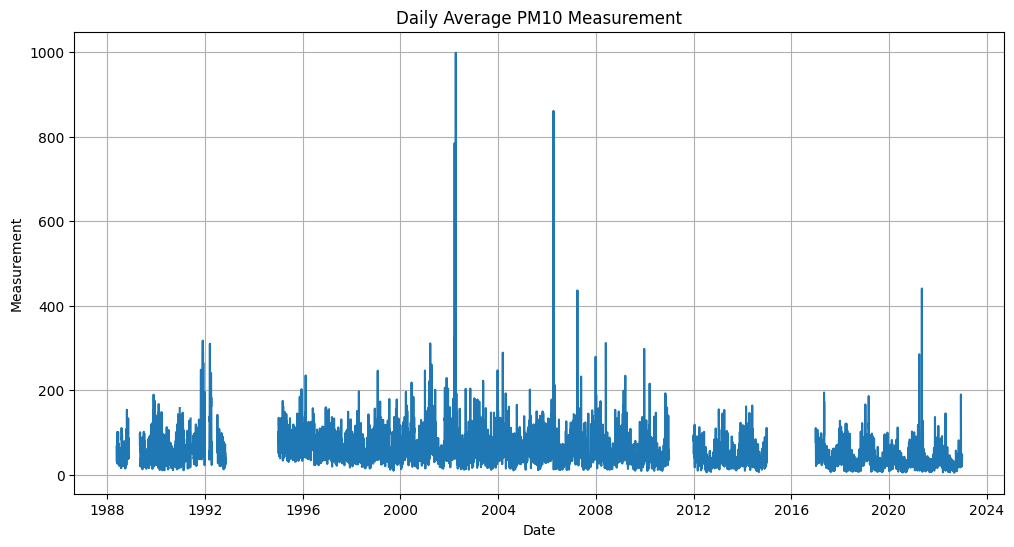

In [17]:
# PM10 Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_pm10_df.index, averaged_pm10_df.values)
plt.title('Daily Average PM10 Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

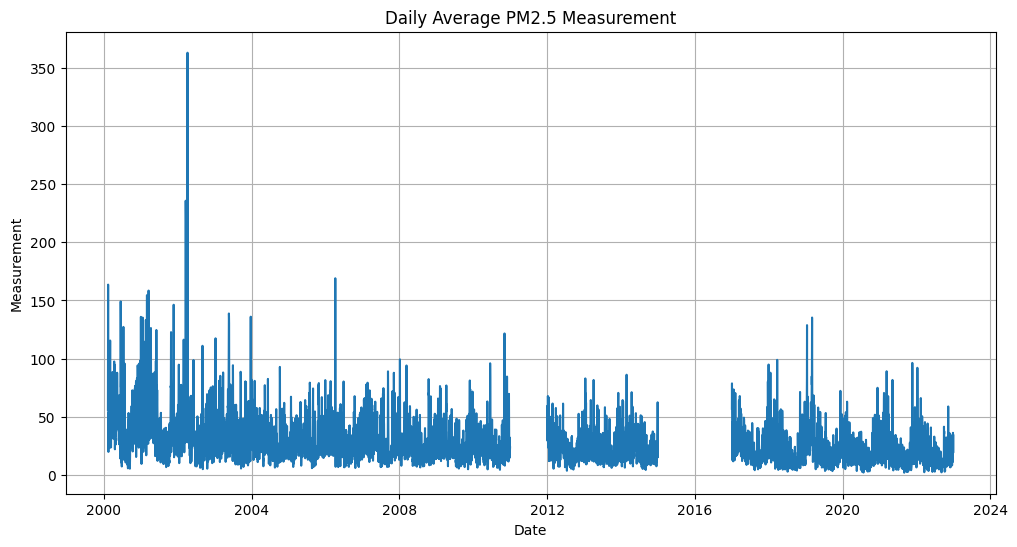

In [18]:
# PM2.5 Daily Average Plot
plt.figure(figsize=(12, 6))
plt.plot(averaged_pm25_df.index, averaged_pm25_df.values)
plt.title('Daily Average PM2.5 Measurement')
plt.xlabel('Date')
plt.ylabel('Measurement')
plt.grid(True)
plt.show()

### Constructing box plots for each pollutant & significance tests for seasonality/yearly trends

In [19]:
# import seaborn for advanced visualizations
import seaborn as sns

#### PM2.5

Original data points: 8360
Data points after removing outliers: 6929
Outliers removed: 1431
Lower bound: -14.69
Upper bound: 65.45


C:\Users\beane\AppData\Local\Temp\ipykernel_31908\440585008.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',


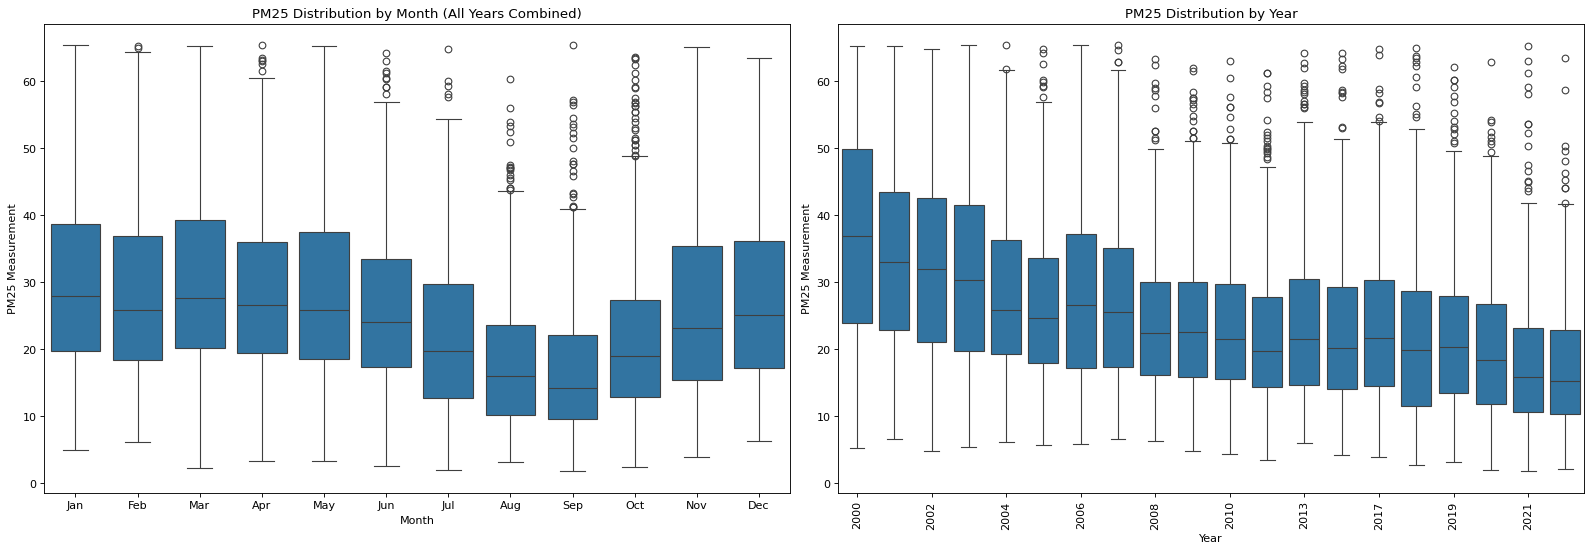

In [20]:
# Convert Series to DataFrame for easier manipulation
monthly_pm25_df = averaged_pm25_df.to_frame(name='PM25')

# Add month and year columns for grouping
monthly_pm25_df['Month'] = monthly_pm25_df.index.month
monthly_pm25_df['Year'] = monthly_pm25_df.index.year

# Remove outliers based on IQR method
Q1 = monthly_pm25_df['PM25'].quantile(0.25)
Q3 = monthly_pm25_df['PM25'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
monthly_pm25_df_filtered = monthly_pm25_df[(monthly_pm25_df['PM25'] >= lower_bound) & 
                                            (monthly_pm25_df['PM25'] <= upper_bound)]

print(f"Original data points: {len(monthly_pm25_df)}")
print(f"Data points after removing outliers: {len(monthly_pm25_df_filtered)}")
print(f"Outliers removed: {len(monthly_pm25_df) - len(monthly_pm25_df_filtered)}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Create side-by-side box plots for seasonal cycle and yearly trends
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

# Box plot by month (seasonal cycle)
p = sns.boxplot(x='Month', y='PM25', data=monthly_pm25_df_filtered, ax=axes[0])
p.set_ylabel("PM25 Measurement", fontsize=10)
p.set_xlabel("Month", fontsize=10)
p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('PM25 Distribution by Month (All Years Combined)', fontsize=12)

# Box plot by year
q = sns.boxplot(x='Year', y='PM25', data=monthly_pm25_df_filtered, ax=axes[1])
q.set_ylabel("PM25 Measurement", fontsize=10)
q.set_xlabel("Year", fontsize=10)
axes[1].set_title('PM25 Distribution by Year', fontsize=12)

# Reduce number of ticks on x-axis for better readability
plt.sca(axes[1])
plt.xticks(np.arange(0, len(monthly_pm25_df_filtered['Year'].unique()), 2), 
           monthly_pm25_df_filtered['Year'].unique()[::2], rotation=90)

plt.tight_layout()
plt.show()

In [21]:
print("="*70)
print("SEASONALITY SIGNIFICANCE TEST FOR PM2.5 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no seasonality in PM2.5 levels")
print("Alternative Hypothesis (H₁): There is seasonality in PM2.5 levels")
print("Significance Level: α = 0.05")
print()

# Separate data by month
monthly_groups = [monthly_pm25_df_filtered[monthly_pm25_df_filtered['Month'] == i]['PM25'].values 
                  for i in range(1, 13)]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across months
h_statistic, p_value = stats.kruskal(*monthly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS statistically significant seasonality in PM2.5 levels")
    print(f"            (p = {p_value} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant seasonality in PM25 levels")
    print(f"            (p = {p_value} >= 0.05)")

print()
print("="*70)
print("DESCRIPTIVE STATISTICS BY MONTH")
print("="*70)

# Calculate mean and std for each month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"{'Month':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)

for i, month_name in enumerate(month_names, 1):
    month_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Month'] == i]['PM25']
    print(f"{month_name:<6} {month_data.mean():<10.2f} {month_data.std():<10.2f} "
          f"{month_data.median():<10.2f} {len(month_data):<8}")

print()
print("="*70)
print("EFFECT SIZE")
print("="*70)

# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_pm25_df_filtered)
eta_squared = (h_statistic - 12 + 1) / (n - 12)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()
if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Dunn's test
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Month Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing months with highest and lowest mean PM25 levels:")
    print()
    
    # Find months with max and min means
    month_means = [(i, monthly_pm25_df_filtered[monthly_pm25_df_filtered['Month'] == i]['PM25'].mean()) 
                   for i in range(1, 13)]
    month_means.sort(key=lambda x: x[1])
    
    min_month = month_means[0][0]
    max_month = month_means[-1][0]
    
    min_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Month'] == min_month]['PM25']
    max_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Month'] == max_month]['PM25']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {month_names[min_month-1]} (mean = {month_means[0][1]:.2f})")
    print(f"Highest mean: {month_names[max_month-1]} (mean = {month_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc:.6f}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two months are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two months are NOT significantly different (p >= 0.05)")

print()
print("="*70)

SEASONALITY SIGNIFICANCE TEST FOR PM2.5 LEVELS

Null Hypothesis (H₀): There is no seasonality in PM2.5 levels
Alternative Hypothesis (H₁): There is seasonality in PM2.5 levels
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 872.6592
P-value: 4.669474868782166e-180

DECISION: REJECT the null hypothesis
CONCLUSION: There IS statistically significant seasonality in PM2.5 levels
            (p = 4.669474868782166e-180 < 0.05)

DESCRIPTIVE STATISTICS BY MONTH
Month  Mean       Std Dev    Median     N       
----------------------------------------------------------------------
Jan    30.02      13.38      27.91      545     
Feb    29.10      13.57      25.87      508     
Mar    30.29      13.55      27.55      568     
Apr    28.43      12.76      26.59      578     
May    28.35      13.80      25.88      590     
Jun    25.96      12.20      24.05      572     
Jul    22.16      12.38      19.69      606     
Aug    18.06      10.17      15.98      618     
Sep    17.01

In [22]:
print("="*70)
print("YEARLY TREND SIGNIFICANCE TEST FOR PM25 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no significant difference in PM25 levels across years")
print("Alternative Hypothesis (H₁): There is a significant difference in PM25 levels across years")
print("Significance Level: α = 0.05")
print()

# Separate data by year
yearly_groups = [monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == year]['PM25'].values 
                 for year in sorted(monthly_pm25_df_filtered['Year'].unique())]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across years
h_statistic, p_value = stats.kruskal(*yearly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.10e}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS a statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} >= 0.05)")
print()

print("="*70)
print("DESCRIPTIVE STATISTICS BY YEAR")
print("="*70)
years = sorted(monthly_pm25_df_filtered['Year'].unique())
print(f"{'Year':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)
for year in years:
    year_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == year]['PM25']
    print(f"{year:<6} {year_data.mean():<10.2f} {year_data.std():<10.2f} "
          f"{year_data.median():<10.2f} {len(year_data):<8}")
print()

print("="*70)
print("EFFECT SIZE")
print("="*70)
# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_pm25_df_filtered)
k = len(years)  # number of groups (years)
eta_squared = (h_statistic - k + 1) / (n - k)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()

if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
    
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Mann-Whitney U
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Year Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing years with highest and lowest mean SO2 levels:")
    print()
    
    # Find years with max and min means
    year_means = [(year, monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == year]['PM25'].mean()) 
                  for year in years]
    year_means.sort(key=lambda x: x[1])
    
    min_year = year_means[0][0]
    max_year = year_means[-1][0]
    
    min_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == min_year]['PM25']
    max_data = monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == max_year]['PM25']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {min_year} (mean = {year_means[0][1]:.2f})")
    print(f"Highest mean: {max_year} (mean = {year_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two years are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two years are NOT significantly different (p >= 0.05)")
    
    # Additional: Test for monotonic trend using Spearman correlation
    print()
    print("="*70)
    print("TREND ANALYSIS: Spearman Correlation")
    print("="*70)
    print("Testing for monotonic trend over time:")
    print()
    
    # Calculate mean PM25 for each year
    year_mean_values = [monthly_pm25_df_filtered[monthly_pm25_df_filtered['Year'] == year]['PM25'].mean() 
                        for year in years]
    
    spearman_corr, spearman_p = stats.spearmanr(years, year_mean_values)
    
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
    print(f"P-value: {spearman_p}")
    print()
    
    if spearman_p < 0.05:
        if spearman_corr > 0:
            print("CONCLUSION: There IS a statistically significant INCREASING trend over years")
        else:
            print("CONCLUSION: There IS a statistically significant DECREASING trend over years")
    else:
        print("CONCLUSION: There is NO statistically significant monotonic trend over years")

print()
print("="*70)

YEARLY TREND SIGNIFICANCE TEST FOR PM25 LEVELS

Null Hypothesis (H₀): There is no significant difference in PM25 levels across years
Alternative Hypothesis (H₁): There is a significant difference in PM25 levels across years
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 824.4251
P-value: 1.3782131630e-162

DECISION: REJECT the null hypothesis
CONCLUSION: There IS a statistically significant difference in SO2 levels across years
            (p = 1.3782131630e-162 < 0.05)

DESCRIPTIVE STATISTICS BY YEAR
Year   Mean       Std Dev    Median     N       
----------------------------------------------------------------------
2000   36.76      15.72      36.92      254     
2001   33.95      14.20      33.02      303     
2002   32.30      14.32      32.01      329     
2003   31.00      13.80      30.34      324     
2004   28.21      12.17      25.86      358     
2005   27.07      12.47      24.67      355     
2006   27.88      13.42      26.50      356     
2007   27.60

#### PM10

Original data points: 12644
Data points after removing outliers: 9990
Outliers removed: 2654
Lower bound: -26.74
Upper bound: 130.25


C:\Users\beane\AppData\Local\Temp\ipykernel_31908\2322400497.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',


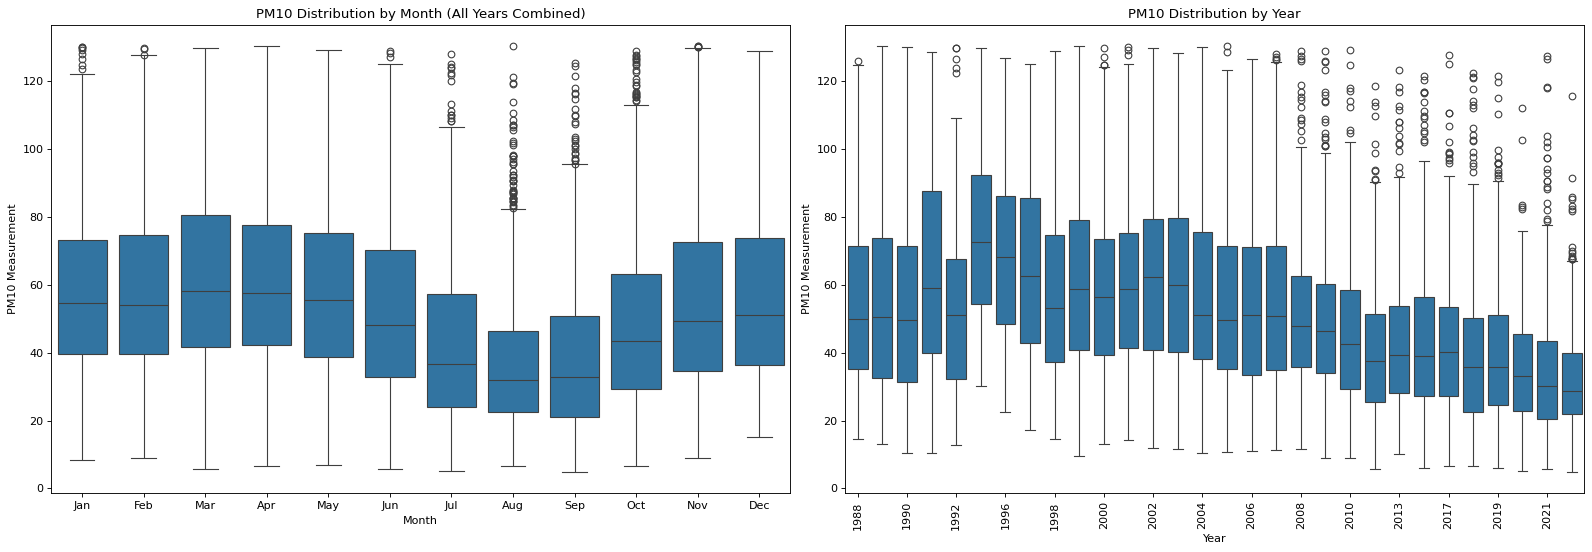

In [23]:
# Convert Series to DataFrame for easier manipulation
monthly_pm10_df = averaged_pm10_df.to_frame(name='PM10')

# Add month and year columns for grouping
monthly_pm10_df['Month'] = monthly_pm10_df.index.month
monthly_pm10_df['Year'] = monthly_pm10_df.index.year

# Remove outliers based on IQR method
Q1 = monthly_pm10_df['PM10'].quantile(0.25)
Q3 = monthly_pm10_df['PM10'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
monthly_pm10_df_filtered = monthly_pm10_df[(monthly_pm10_df['PM10'] >= lower_bound) & 
                                            (monthly_pm10_df['PM10'] <= upper_bound)]

print(f"Original data points: {len(monthly_pm10_df)}")
print(f"Data points after removing outliers: {len(monthly_pm10_df_filtered)}")
print(f"Outliers removed: {len(monthly_pm10_df) - len(monthly_pm10_df_filtered)}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Create side-by-side box plots for seasonal cycle and yearly trends
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

# Box plot by month (seasonal cycle)
p = sns.boxplot(x='Month', y='PM10', data=monthly_pm10_df_filtered, ax=axes[0])
p.set_ylabel("PM10 Measurement", fontsize=10)
p.set_xlabel("Month", fontsize=10)
p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('PM10 Distribution by Month (All Years Combined)', fontsize=12)

# Box plot by year
q = sns.boxplot(x='Year', y='PM10', data=monthly_pm10_df_filtered, ax=axes[1])
q.set_ylabel("PM10 Measurement", fontsize=10)
q.set_xlabel("Year", fontsize=10)
axes[1].set_title('PM10 Distribution by Year', fontsize=12)

# Reduce number of ticks on x-axis for better readability
plt.sca(axes[1])
plt.xticks(np.arange(0, len(monthly_pm10_df_filtered['Year'].unique()), 2), 
           monthly_pm10_df_filtered['Year'].unique()[::2], rotation=90)

plt.tight_layout()
plt.show()

In [24]:
print("="*70)
print("SEASONALITY SIGNIFICANCE TEST FOR PM10 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no seasonality in PM10 levels")
print("Alternative Hypothesis (H₁): There is seasonality in PM10 levels")
print("Significance Level: α = 0.05")
print()

# Separate data by month
monthly_groups = [monthly_pm10_df_filtered[monthly_pm10_df_filtered['Month'] == i]['PM10'].values 
                  for i in range(1, 13)]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across months
h_statistic, p_value = stats.kruskal(*monthly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS statistically significant seasonality in PM10 levels")
    print(f"            (p = {p_value} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant seasonality in PM10 levels")
    print(f"            (p = {p_value} >= 0.05)")

print()
print("="*70)
print("DESCRIPTIVE STATISTICS BY MONTH")
print("="*70)

# Calculate mean and std for each month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"{'Month':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)

for i, month_name in enumerate(month_names, 1):
    month_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Month'] == i]['PM10']
    print(f"{month_name:<6} {month_data.mean():<10.2f} {month_data.std():<10.2f} "
          f"{month_data.median():<10.2f} {len(month_data):<8}")

print()
print("="*70)
print("EFFECT SIZE")
print("="*70)

# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_pm10_df_filtered)
eta_squared = (h_statistic - 12 + 1) / (n - 12)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()
if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Dunn's test
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Month Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing months with highest and lowest mean PM10 levels:")
    print()
    
    # Find months with max and min means
    month_means = [(i, monthly_pm10_df_filtered[monthly_pm10_df_filtered['Month'] == i]['PM10'].mean()) 
                   for i in range(1, 13)]
    month_means.sort(key=lambda x: x[1])
    
    min_month = month_means[0][0]
    max_month = month_means[-1][0]
    
    min_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Month'] == min_month]['PM10']
    max_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Month'] == max_month]['PM10']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {month_names[min_month-1]} (mean = {month_means[0][1]:.2f})")
    print(f"Highest mean: {month_names[max_month-1]} (mean = {month_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc:.6f}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two months are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two months are NOT significantly different (p >= 0.05)")

print()
print("="*70)

SEASONALITY SIGNIFICANCE TEST FOR PM10 LEVELS

Null Hypothesis (H₀): There is no seasonality in PM10 levels
Alternative Hypothesis (H₁): There is seasonality in PM10 levels
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 1196.9649
P-value: 7.303408960105856e-250

DECISION: REJECT the null hypothesis
CONCLUSION: There IS statistically significant seasonality in PM10 levels
            (p = 7.303408960105856e-250 < 0.05)

DESCRIPTIVE STATISTICS BY MONTH
Month  Mean       Std Dev    Median     N       
----------------------------------------------------------------------
Jan    58.60      25.60      54.67      807     
Feb    58.92      25.96      54.03      724     
Mar    62.77      27.35      58.01      766     
Apr    60.33      25.49      57.53      786     
May    58.12      25.86      55.42      843     
Jun    52.67      26.02      48.04      822     
Jul    42.43      23.54      36.65      918     
Aug    37.06      21.15      31.82      929     
Sep    38.58   

In [25]:
print("="*70)
print("YEARLY TREND SIGNIFICANCE TEST FOR PM10 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no significant difference in PM10 levels across years")
print("Alternative Hypothesis (H₁): There is a significant difference in PM10 levels across years")
print("Significance Level: α = 0.05")
print()

# Separate data by year
yearly_groups = [monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == year]['PM10'].values 
                 for year in sorted(monthly_pm10_df_filtered['Year'].unique())]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across years
h_statistic, p_value = stats.kruskal(*yearly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.10e}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS a statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} >= 0.05)")
print()

print("="*70)
print("DESCRIPTIVE STATISTICS BY YEAR")
print("="*70)
years = sorted(monthly_pm10_df_filtered['Year'].unique())
print(f"{'Year':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)
for year in years:
    year_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == year]['PM10']
    print(f"{year:<6} {year_data.mean():<10.2f} {year_data.std():<10.2f} "
          f"{year_data.median():<10.2f} {len(year_data):<8}")
print()

print("="*70)
print("EFFECT SIZE")
print("="*70)
# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_pm10_df_filtered)
k = len(years)  # number of groups (years)
eta_squared = (h_statistic - k + 1) / (n - k)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()

if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
    
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Mann-Whitney U
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Year Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing years with highest and lowest mean SO2 levels:")
    print()
    
    # Find years with max and min means
    year_means = [(year, monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == year]['PM10'].mean()) 
                  for year in years]
    year_means.sort(key=lambda x: x[1])
    
    min_year = year_means[0][0]
    max_year = year_means[-1][0]
    
    min_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == min_year]['PM10']
    max_data = monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == max_year]['PM10']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {min_year} (mean = {year_means[0][1]:.2f})")
    print(f"Highest mean: {max_year} (mean = {year_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two years are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two years are NOT significantly different (p >= 0.05)")
    
    # Additional: Test for monotonic trend using Spearman correlation
    print()
    print("="*70)
    print("TREND ANALYSIS: Spearman Correlation")
    print("="*70)
    print("Testing for monotonic trend over time:")
    print()
    
    # Calculate mean PM10 for each year
    year_mean_values = [monthly_pm10_df_filtered[monthly_pm10_df_filtered['Year'] == year]['PM10'].mean() 
                        for year in years]
    
    spearman_corr, spearman_p = stats.spearmanr(years, year_mean_values)
    
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
    print(f"P-value: {spearman_p}")
    print()
    
    if spearman_p < 0.05:
        if spearman_corr > 0:
            print("CONCLUSION: There IS a statistically significant INCREASING trend over years")
        else:
            print("CONCLUSION: There IS a statistically significant DECREASING trend over years")
    else:
        print("CONCLUSION: There is NO statistically significant monotonic trend over years")

print()
print("="*70)

YEARLY TREND SIGNIFICANCE TEST FOR PM10 LEVELS

Null Hypothesis (H₀): There is no significant difference in PM10 levels across years
Alternative Hypothesis (H₁): There is a significant difference in PM10 levels across years
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 1718.5721
P-value: 0.0000000000e+00

DECISION: REJECT the null hypothesis
CONCLUSION: There IS a statistically significant difference in SO2 levels across years
            (p = 0.0000000000e+00 < 0.05)

DESCRIPTIVE STATISTICS BY YEAR
Year   Mean       Std Dev    Median     N       
----------------------------------------------------------------------
1988   55.84      27.77      49.98      170     
1989   56.23      28.30      50.54      230     
1990   53.48      27.26      49.58      327     
1991   62.87      28.30      59.12      266     
1992   53.99      27.11      51.19      150     
1995   74.49      24.74      72.59      341     
1996   68.80      25.26      68.27      354     
1997   65.44 

#### NO2

Original data points: 12784
Data points after removing outliers: 11414
Outliers removed: 1370
Lower bound: -0.01
Upper bound: 0.05


C:\Users\beane\AppData\Local\Temp\ipykernel_31908\3336195472.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',


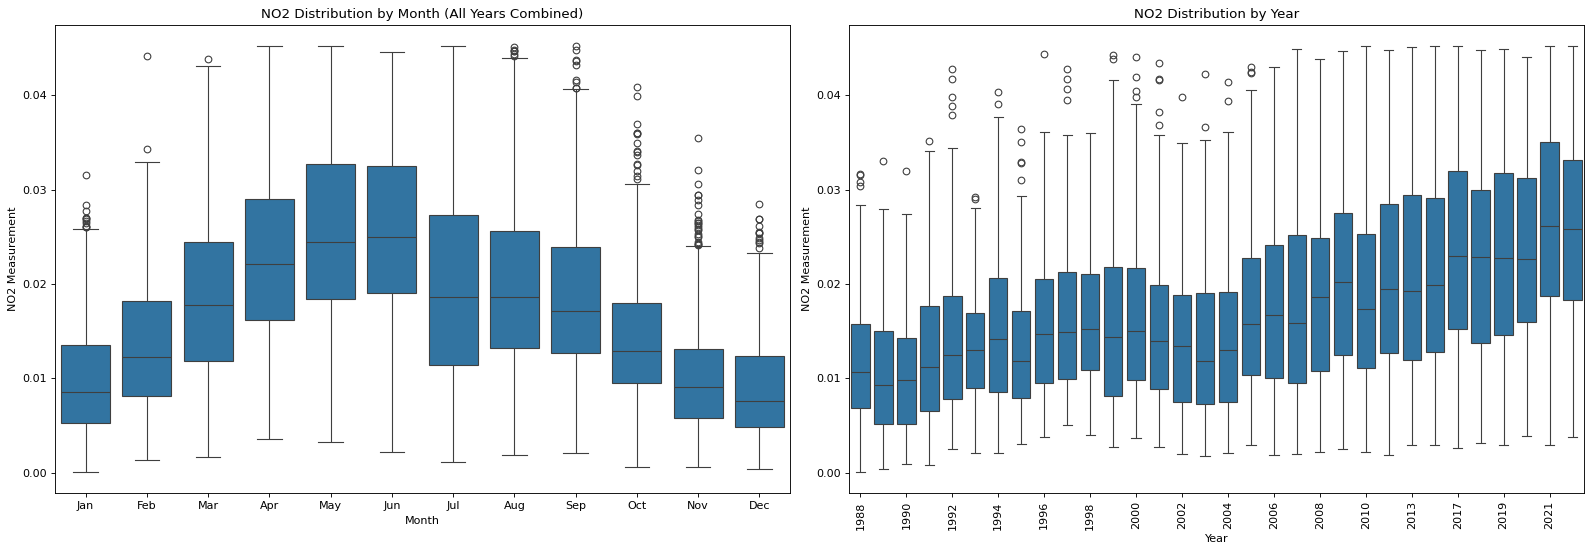

In [26]:
# Convert Series to DataFrame for easier manipulation
monthly_nitrogendioxide_df = averaged_nitrogendioxide_df.to_frame(name='NO2')

# Add month and year columns for grouping
monthly_nitrogendioxide_df['Month'] = monthly_nitrogendioxide_df.index.month
monthly_nitrogendioxide_df['Year'] = monthly_nitrogendioxide_df.index.year
# Remove outliers based on IQR method
Q1 = monthly_nitrogendioxide_df['NO2'].quantile(0.25)
Q3 = monthly_nitrogendioxide_df['NO2'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
monthly_nitrogendioxide_df_filtered = monthly_nitrogendioxide_df[(monthly_nitrogendioxide_df['NO2'] >= lower_bound) & 
                                            (monthly_nitrogendioxide_df['NO2'] <= upper_bound)]
print(f"Original data points: {len(monthly_nitrogendioxide_df)}")
print(f"Data points after removing outliers: {len(monthly_nitrogendioxide_df_filtered)}")
print(f"Outliers removed: {len(monthly_nitrogendioxide_df) - len(monthly_nitrogendioxide_df_filtered)}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Create side-by-side box plots for seasonal cycle and yearly trends
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

# Box plot by month (seasonal cycle)
p = sns.boxplot(x='Month', y='NO2', data=monthly_nitrogendioxide_df_filtered, ax=axes[0])
p.set_ylabel("NO2 Measurement", fontsize=10)
p.set_xlabel("Month", fontsize=10)
p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('NO2 Distribution by Month (All Years Combined)', fontsize=12)
# Box plot by year
q = sns.boxplot(x='Year', y='NO2', data=monthly_nitrogendioxide_df_filtered, ax=axes[1])
q.set_ylabel("NO2 Measurement", fontsize=10)
q.set_xlabel("Year", fontsize=10)
axes[1].set_title('NO2 Distribution by Year', fontsize=12)

# Reduce number of ticks on x-axis for better readability
plt.sca(axes[1])
plt.xticks(np.arange(0, len(monthly_nitrogendioxide_df_filtered['Year'].unique()), 2), 
           monthly_nitrogendioxide_df_filtered['Year'].unique()[::2], rotation=90)

plt.tight_layout()
plt.show()

In [27]:
print("="*70)
print("SEASONALITY SIGNIFICANCE TEST FOR NO2 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no seasonality in NO2 levels")
print("Alternative Hypothesis (H₁): There is seasonality in NO2 levels")
print("Significance Level: α = 0.05")
print()

# Separate data by month
monthly_groups = [monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Month'] == i]['NO2'].values 
                  for i in range(1, 13)]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across months
h_statistic, p_value = stats.kruskal(*monthly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS statistically significant seasonality in PM2.5 levels")
    print(f"            (p = {p_value} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant seasonality in PM2.5 levels")
    print(f"            (p = {p_value} >= 0.05)")

print()
print("="*70)
print("DESCRIPTIVE STATISTICS BY MONTH")
print("="*70)

# Calculate mean and std for each month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"{'Month':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)

for i, month_name in enumerate(month_names, 1):
    month_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Month'] == i]['NO2']
    print(f"{month_name:<6} {month_data.mean():<10.2f} {month_data.std():<10.2f} "
          f"{month_data.median():<10.2f} {len(month_data):<8}")

print()
print("="*70)
print("EFFECT SIZE")
print("="*70)

# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_nitrogendioxide_df_filtered)
eta_squared = (h_statistic - 12 + 1) / (n - 12)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()
if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Dunn's test
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Month Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing months with highest and lowest mean NO2 levels:")
    print()
    
    # Find months with max and min means
    month_means = [(i, monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Month'] == i]['NO2'].mean()) 
                   for i in range(1, 13)]
    month_means.sort(key=lambda x: x[1])
    
    min_month = month_means[0][0]
    max_month = month_means[-1][0]
    
    min_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Month'] == min_month]['NO2']
    max_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Month'] == max_month]['NO2']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {month_names[min_month-1]} (mean = {month_means[0][1]:.2f})")
    print(f"Highest mean: {month_names[max_month-1]} (mean = {month_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two months are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two months are NOT significantly different (p >= 0.05)")

print()
print("="*70)

SEASONALITY SIGNIFICANCE TEST FOR NO2 LEVELS

Null Hypothesis (H₀): There is no seasonality in NO2 levels
Alternative Hypothesis (H₁): There is seasonality in NO2 levels
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 3974.7662
P-value: 0.0

DECISION: REJECT the null hypothesis
CONCLUSION: There IS statistically significant seasonality in PM2.5 levels
            (p = 0.0 < 0.05)

DESCRIPTIVE STATISTICS BY MONTH
Month  Mean       Std Dev    Median     N       
----------------------------------------------------------------------
Jan    0.01       0.01       0.01       992     
Feb    0.01       0.01       0.01       904     
Mar    0.02       0.01       0.02       991     
Apr    0.02       0.01       0.02       938     
May    0.03       0.01       0.02       918     
Jun    0.03       0.01       0.02       891     
Jul    0.02       0.01       0.02       959     
Aug    0.02       0.01       0.02       978     
Sep    0.02       0.01       0.02       956     
Oct   

In [28]:
print("="*70)
print("YEARLY TREND SIGNIFICANCE TEST FOR NO2 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no significant difference in NO2 levels across years")
print("Alternative Hypothesis (H₁): There is a significant difference in NO2 levels across years")
print("Significance Level: α = 0.05")
print()

# Separate data by year
yearly_groups = [monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == year]['NO2'].values 
                 for year in sorted(monthly_nitrogendioxide_df_filtered['Year'].unique())]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across years
h_statistic, p_value = stats.kruskal(*yearly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.10e}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS a statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} >= 0.05)")
print()

print("="*70)
print("DESCRIPTIVE STATISTICS BY YEAR")
print("="*70)
years = sorted(monthly_nitrogendioxide_df_filtered['Year'].unique())
print(f"{'Year':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)
for year in years:
    year_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == year]['NO2']
    print(f"{year:<6} {year_data.mean():<10.2f} {year_data.std():<10.2f} "
          f"{year_data.median():<10.2f} {len(year_data):<8}")
print()

print("="*70)
print("EFFECT SIZE")
print("="*70)
# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_nitrogendioxide_df_filtered)
k = len(years)  # number of groups (years)
eta_squared = (h_statistic - k + 1) / (n - k)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()

if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
    
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Mann-Whitney U
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Year Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing years with highest and lowest mean SO2 levels:")
    print()
    
    # Find years with max and min means
    year_means = [(year, monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == year]['NO2'].mean()) 
                  for year in years]
    year_means.sort(key=lambda x: x[1])
    
    min_year = year_means[0][0]
    max_year = year_means[-1][0]
    
    min_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == min_year]['NO2']
    max_data = monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == max_year]['NO2']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {min_year} (mean = {year_means[0][1]:.2f})")
    print(f"Highest mean: {max_year} (mean = {year_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two years are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two years are NOT significantly different (p >= 0.05)")
    
    # Additional: Test for monotonic trend using Spearman correlation
    print()
    print("="*70)
    print("TREND ANALYSIS: Spearman Correlation")
    print("="*70)
    print("Testing for monotonic trend over time:")
    print()
    
    # Calculate mean NO2 for each year
    year_mean_values = [monthly_nitrogendioxide_df_filtered[monthly_nitrogendioxide_df_filtered['Year'] == year]['NO2'].mean() 
                        for year in years]
    
    spearman_corr, spearman_p = stats.spearmanr(years, year_mean_values)
    
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
    print(f"P-value: {spearman_p}")
    print()
    
    if spearman_p < 0.05:
        if spearman_corr > 0:
            print("CONCLUSION: There IS a statistically significant INCREASING trend over years")
        else:
            print("CONCLUSION: There IS a statistically significant DECREASING trend over years")
    else:
        print("CONCLUSION: There is NO statistically significant monotonic trend over years")

print()
print("="*70)

YEARLY TREND SIGNIFICANCE TEST FOR NO2 LEVELS

Null Hypothesis (H₀): There is no significant difference in NO2 levels across years
Alternative Hypothesis (H₁): There is a significant difference in NO2 levels across years
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 1978.0938
P-value: 0.0000000000e+00

DECISION: REJECT the null hypothesis
CONCLUSION: There IS a statistically significant difference in SO2 levels across years
            (p = 0.0000000000e+00 < 0.05)

DESCRIPTIVE STATISTICS BY YEAR
Year   Mean       Std Dev    Median     N       
----------------------------------------------------------------------
1988   0.01       0.01       0.01       322     
1989   0.01       0.01       0.01       365     
1990   0.01       0.01       0.01       353     
1991   0.01       0.01       0.01       365     
1992   0.01       0.01       0.01       366     
1993   0.01       0.01       0.01       365     
1994   0.02       0.01       0.01       365     
1995   0.01     

#### SO2

Original data points: 12784
Data points after removing outliers: 10013
Outliers removed: 2771
Lower bound: -0.01
Upper bound: 0.02


C:\Users\beane\AppData\Local\Temp\ipykernel_31908\4181738869.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',


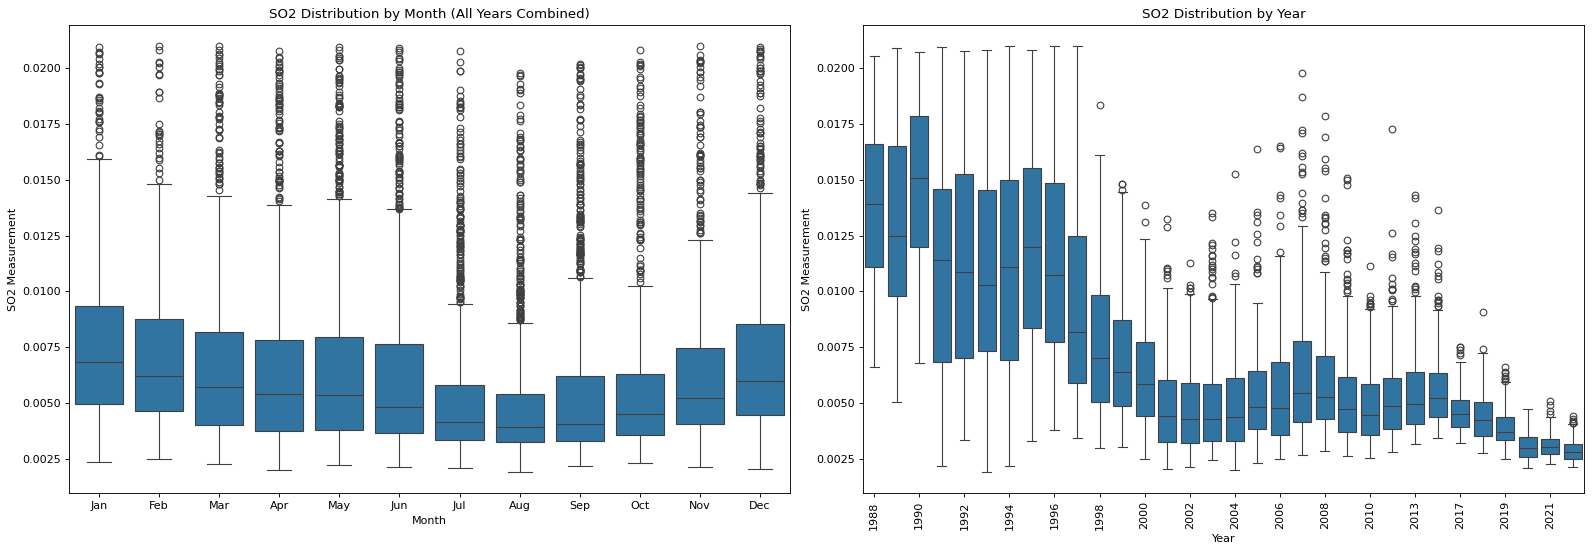

In [29]:
# Convert Series to DataFrame for easier manipulation
monthly_sulfurdioxide_df = averaged_sulfurdioxide_df.to_frame(name='SO2')

# Add month and year columns for grouping
monthly_sulfurdioxide_df['Month'] = monthly_sulfurdioxide_df.index.month
monthly_sulfurdioxide_df['Year'] = monthly_sulfurdioxide_df.index.year
# Remove outliers based on IQR method
Q1 = monthly_sulfurdioxide_df['SO2'].quantile(0.25)
Q3 = monthly_sulfurdioxide_df['SO2'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
monthly_sulfurdioxide_df_filtered = monthly_sulfurdioxide_df[(monthly_sulfurdioxide_df['SO2'] >= lower_bound) & 
                                            (monthly_sulfurdioxide_df['SO2'] <= upper_bound)]

print(f"Original data points: {len(monthly_sulfurdioxide_df)}")
print(f"Data points after removing outliers: {len(monthly_sulfurdioxide_df_filtered)}")
print(f"Outliers removed: {len(monthly_sulfurdioxide_df) - len(monthly_sulfurdioxide_df_filtered)}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Create side-by-side box plots for seasonal cycle and yearly trends
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

# Box plot by month (seasonal cycle)
p = sns.boxplot(x='Month', y='SO2', data=monthly_sulfurdioxide_df_filtered, ax=axes[0])
p.set_ylabel("SO2 Measurement", fontsize=10)
p.set_xlabel("Month", fontsize=10)
p.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].set_title('SO2 Distribution by Month (All Years Combined)', fontsize=12)
# Box plot by year
q = sns.boxplot(x='Year', y='SO2', data=monthly_sulfurdioxide_df_filtered, ax=axes[1])
q.set_ylabel("SO2 Measurement", fontsize=10)
q.set_xlabel("Year", fontsize=10)
axes[1].set_title('SO2 Distribution by Year', fontsize=12)

# Reduce number of ticks on x-axis for better readability
plt.sca(axes[1])
plt.xticks(np.arange(0, len(monthly_sulfurdioxide_df_filtered['Year'].unique()), 2), 
           monthly_sulfurdioxide_df_filtered['Year'].unique()[::2], rotation=90)

plt.tight_layout()
plt.show()

In [30]:
print("="*70)
print("SEASONALITY SIGNIFICANCE TEST FOR SO2 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no seasonality in SO2 levels")
print("Alternative Hypothesis (H₁): There is seasonality in SO2 levels")
print("Significance Level: α = 0.05")
print()

# Separate data by month
monthly_groups = [monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Month'] == i]['SO2'].values 
                  for i in range(1, 13)]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across months
h_statistic, p_value = stats.kruskal(*monthly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS statistically significant seasonality in SO2 levels")
    print(f"            (p = {p_value} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant seasonality in SO2 levels")
    print(f"            (p = {p_value} >= 0.05)")

print()
print("="*70)
print("DESCRIPTIVE STATISTICS BY MONTH")
print("="*70)

# Calculate mean and std for each month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"{'Month':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)

for i, month_name in enumerate(month_names, 1):
    month_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Month'] == i]['SO2']
    print(f"{month_name:<6} {month_data.mean():<10.2f} {month_data.std():<10.2f} "
          f"{month_data.median():<10.2f} {len(month_data):<8}")

print()
print("="*70)
print("EFFECT SIZE")
print("="*70)

# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_sulfurdioxide_df_filtered)
eta_squared = (h_statistic - 12 + 1) / (n - 12)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()
if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Dunn's test
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Month Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing months with highest and lowest mean SO2 levels:")
    print()
    
    # Find months with max and min means
    month_means = [(i, monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Month'] == i]['SO2'].mean()) 
                   for i in range(1, 13)]
    month_means.sort(key=lambda x: x[1])
    
    min_month = month_means[0][0]
    max_month = month_means[-1][0]
    
    min_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Month'] == min_month]['SO2']
    max_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Month'] == max_month]['SO2']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {month_names[min_month-1]} (mean = {month_means[0][1]:.2f})")
    print(f"Highest mean: {month_names[max_month-1]} (mean = {month_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two months are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two months are NOT significantly different (p >= 0.05)")

print()
print("="*70)

SEASONALITY SIGNIFICANCE TEST FOR SO2 LEVELS

Null Hypothesis (H₀): There is no seasonality in SO2 levels
Alternative Hypothesis (H₁): There is seasonality in SO2 levels
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 802.7505
P-value: 4.863595332249666e-165

DECISION: REJECT the null hypothesis
CONCLUSION: There IS statistically significant seasonality in SO2 levels
            (p = 4.863595332249666e-165 < 0.05)

DESCRIPTIVE STATISTICS BY MONTH
Month  Mean       Std Dev    Median     N       
----------------------------------------------------------------------
Jan    0.01       0.00       0.01       743     
Feb    0.01       0.00       0.01       676     
Mar    0.01       0.00       0.01       779     
Apr    0.01       0.00       0.01       782     
May    0.01       0.00       0.01       865     
Jun    0.01       0.00       0.00       930     
Jul    0.01       0.00       0.00       979     
Aug    0.01       0.00       0.00       981     
Sep    0.01       0.

In [31]:
print("="*70)
print("YEARLY TREND SIGNIFICANCE TEST FOR SO2 LEVELS")
print("="*70)
print()
print("Null Hypothesis (H₀): There is no significant difference in SO2 levels across years")
print("Alternative Hypothesis (H₁): There is a significant difference in SO2 levels across years")
print("Significance Level: α = 0.05")
print()

# Separate data by year
yearly_groups = [monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == year]['SO2'].values 
                 for year in sorted(monthly_sulfurdioxide_df_filtered['Year'].unique())]

# Perform Kruskal-Wallis H-test (non-parametric alternative to one-way ANOVA)
# This tests if the distributions differ across years
h_statistic, p_value = stats.kruskal(*yearly_groups)

print("="*70)
print("KRUSKAL-WALLIS H-TEST")
print("="*70)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.10e}")
print()

if p_value < 0.05:
    print("DECISION: REJECT the null hypothesis")
    print("CONCLUSION: There IS a statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} < 0.05)")
else:
    print("DECISION: FAIL TO REJECT the null hypothesis")
    print("CONCLUSION: There is NO statistically significant difference in SO2 levels across years")
    print(f"            (p = {p_value:.10e} >= 0.05)")
print()

print("="*70)
print("DESCRIPTIVE STATISTICS BY YEAR")
print("="*70)
years = sorted(monthly_sulfurdioxide_df_filtered['Year'].unique())
print(f"{'Year':<6} {'Mean':<10} {'Std Dev':<10} {'Median':<10} {'N':<8}")
print("-"*70)
for year in years:
    year_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == year]['SO2']
    print(f"{year:<6} {year_data.mean():<10.2f} {year_data.std():<10.2f} "
          f"{year_data.median():<10.2f} {len(year_data):<8}")
print()

print("="*70)
print("EFFECT SIZE")
print("="*70)
# Calculate eta-squared (effect size for Kruskal-Wallis)
n = len(monthly_sulfurdioxide_df_filtered)
k = len(years)  # number of groups (years)
eta_squared = (h_statistic - k + 1) / (n - k)
print(f"Eta-squared (η²): {eta_squared:.4f}")
print()

if eta_squared < 0.01:
    effect_size = "negligible"
elif eta_squared < 0.06:
    effect_size = "small"
elif eta_squared < 0.14:
    effect_size = "medium"
else:
    effect_size = "large"
    
print(f"Effect size interpretation: {effect_size}")
print()

# Optional: Post-hoc pairwise comparisons using Mann-Whitney U
# (if null hypothesis is rejected)
if p_value < 0.05:
    print("="*70)
    print("POST-HOC ANALYSIS: Pairwise Year Comparisons (Mann-Whitney U)")
    print("="*70)
    print("Comparing years with highest and lowest mean SO2 levels:")
    print()
    
    # Find years with max and min means
    year_means = [(year, monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == year]['SO2'].mean()) 
                  for year in years]
    year_means.sort(key=lambda x: x[1])
    
    min_year = year_means[0][0]
    max_year = year_means[-1][0]
    
    min_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == min_year]['SO2']
    max_data = monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == max_year]['SO2']
    
    u_stat, p_val_posthoc = stats.mannwhitneyu(min_data, max_data, alternative='two-sided')
    
    print(f"Lowest mean: {min_year} (mean = {year_means[0][1]:.2f})")
    print(f"Highest mean: {max_year} (mean = {year_means[-1][1]:.2f})")
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"P-value: {p_val_posthoc}")
    print()
    if p_val_posthoc < 0.05:
        print(f"These two years are SIGNIFICANTLY different (p < 0.05)")
    else:
        print(f"These two years are NOT significantly different (p >= 0.05)")
    
    # Additional: Test for monotonic trend using Spearman correlation
    print()
    print("="*70)
    print("TREND ANALYSIS: Spearman Correlation")
    print("="*70)
    print("Testing for monotonic trend over time:")
    print()
    
    # Calculate mean SO2 for each year
    year_mean_values = [monthly_sulfurdioxide_df_filtered[monthly_sulfurdioxide_df_filtered['Year'] == year]['SO2'].mean() 
                        for year in years]
    
    spearman_corr, spearman_p = stats.spearmanr(years, year_mean_values)
    
    print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
    print(f"P-value: {spearman_p}")
    print()
    
    if spearman_p < 0.05:
        if spearman_corr > 0:
            print("CONCLUSION: There IS a statistically significant INCREASING trend over years")
        else:
            print("CONCLUSION: There IS a statistically significant DECREASING trend over years")
    else:
        print("CONCLUSION: There is NO statistically significant monotonic trend over years")

print()
print("="*70)

YEARLY TREND SIGNIFICANCE TEST FOR SO2 LEVELS

Null Hypothesis (H₀): There is no significant difference in SO2 levels across years
Alternative Hypothesis (H₁): There is a significant difference in SO2 levels across years
Significance Level: α = 0.05

KRUSKAL-WALLIS H-TEST
H-statistic: 5140.3027
P-value: 0.0000000000e+00

DECISION: REJECT the null hypothesis
CONCLUSION: There IS a statistically significant difference in SO2 levels across years
            (p = 0.0000000000e+00 < 0.05)

DESCRIPTIVE STATISTICS BY YEAR
Year   Mean       Std Dev    Median     N       
----------------------------------------------------------------------
1988   0.01       0.00       0.01       90      
1989   0.01       0.00       0.01       114     
1990   0.01       0.00       0.02       94      
1991   0.01       0.00       0.01       137     
1992   0.01       0.01       0.01       157     
1993   0.01       0.00       0.01       219     
1994   0.01       0.00       0.01       253     
1995   0.01     

### Normalize & plot pollutant medians in one plot

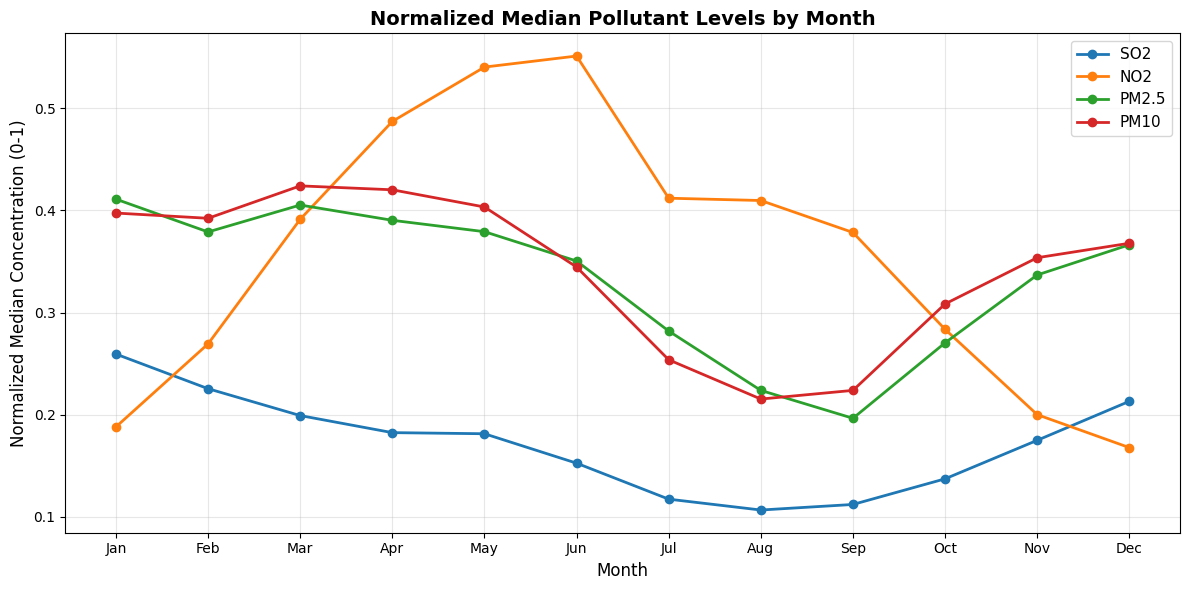

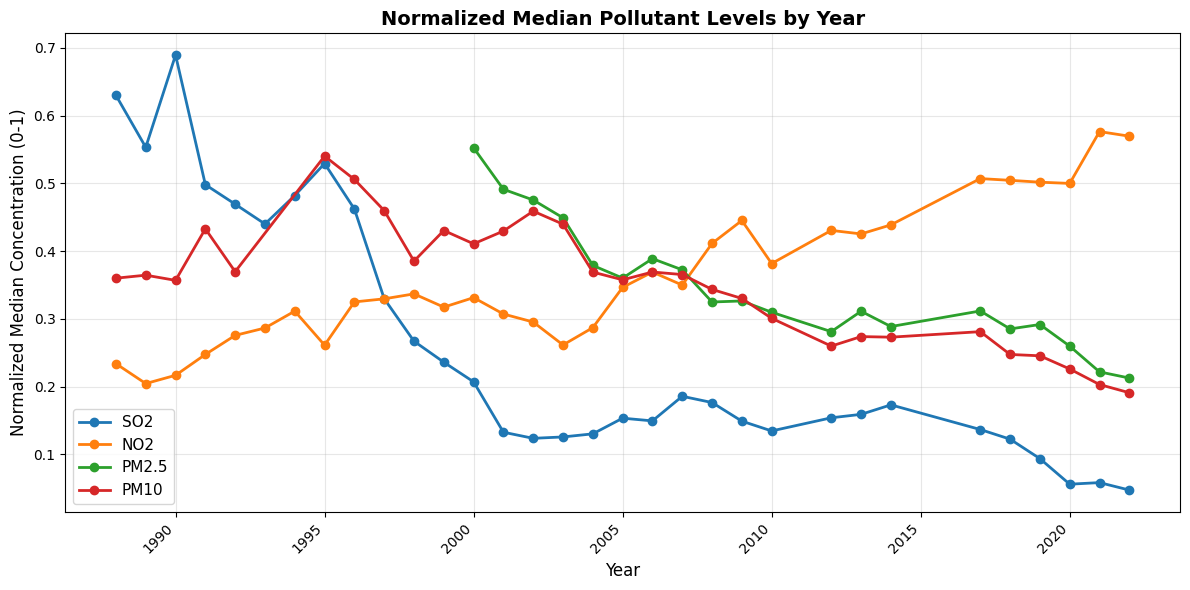

In [32]:
# Prepare data for all pollutants
pollutants = {
    'SO2': averaged_sulfurdioxide_df,
    'NO2': averaged_nitrogendioxide_df,
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe, remove outliers, and normalize
def prepare_and_normalize_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Step 1: Remove outliers FIRST
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    
    # Step 2: Normalize AFTER removing outliers (min-max scaling to 0-1)
    min_val = df_filtered[pollutant_name].min()
    max_val = df_filtered[pollutant_name].max()
    df_filtered[f'{pollutant_name}_normalized'] = (df_filtered[pollutant_name] - min_val) / (max_val - min_val)
    
    return df_filtered

# Prepare all pollutant dataframes
pollutant_dfs = {}
for name, series in pollutants.items():
    pollutant_dfs[name] = prepare_and_normalize_pollutant_data(series, name)

# Plot 1: Normalized Median by Month
plt.figure(figsize=(12, 6), dpi=100)
for pollutant_name, df in pollutant_dfs.items():
    monthly_medians = df.groupby('Month')[f'{pollutant_name}_normalized'].median()
    plt.plot(monthly_medians.index, monthly_medians.values, 
             marker='o', linewidth=2, label=pollutant_name, markersize=6)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Normalized Median Concentration (0-1)', fontsize=12)
plt.title('Normalized Median Pollutant Levels by Month', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Normalized Median by Year
plt.figure(figsize=(12, 6), dpi=100)
for pollutant_name, df in pollutant_dfs.items():
    yearly_medians = df.groupby('Year')[f'{pollutant_name}_normalized'].median()
    plt.plot(yearly_medians.index, yearly_medians.values, 
             marker='o', linewidth=2, label=pollutant_name, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Median Concentration (0-1)', fontsize=12)
plt.title('Normalized Median Pollutant Levels by Year', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Compare early & recent period to analyze monsoon seasonality timing shift

MONSOON SEASONALITY TIMING SHIFT ANALYSIS

Early period: 2000-2009
Recent period: 2010-2022



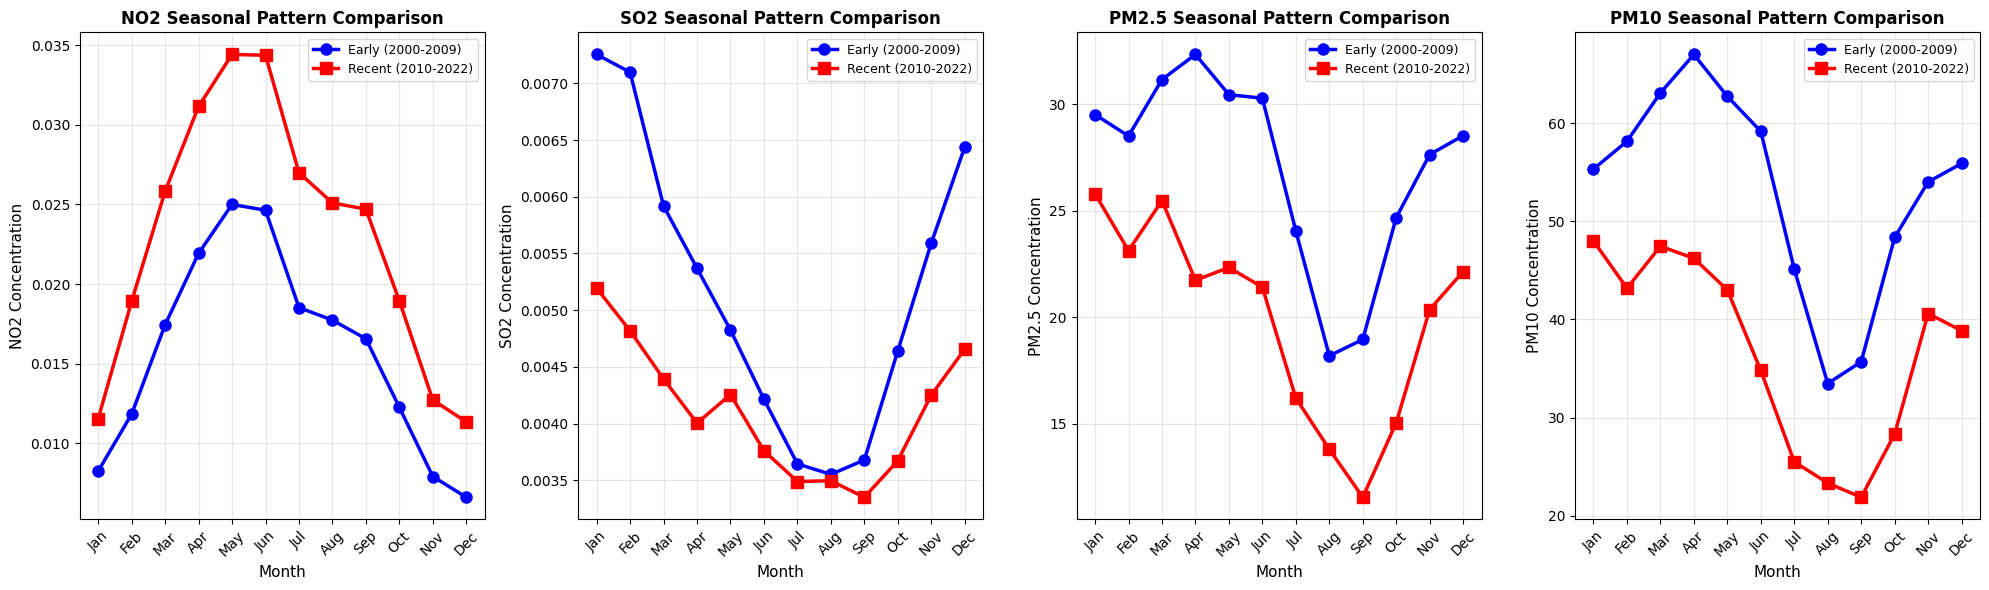

STATISTICAL TESTS FOR MONSOON TIMING SHIFTS


NO2 - PEAK AND TROUGH TIMING ANALYSIS

Peak concentration month:
  Early period (2000-2009): May (Month 5)
  Recent period (2010-2022): May (Month 5)
  Shift: 0 months (no change)

Trough concentration month (monsoon effect):
  Early period (2000-2009): Dec (Month 12)
  Recent period (2010-2022): Dec (Month 12)
  Shift: 0 months (no change)

SO2 - PEAK AND TROUGH TIMING ANALYSIS

Peak concentration month:
  Early period (2000-2009): Jan (Month 1)
  Recent period (2010-2022): Jan (Month 1)
  Shift: 0 months (no change)

Trough concentration month (monsoon effect):
  Early period (2000-2009): Aug (Month 8)
  Recent period (2010-2022): Sep (Month 9)
  Shift: 1 months later

PM2.5 - PEAK AND TROUGH TIMING ANALYSIS

Peak concentration month:
  Early period (2000-2009): Apr (Month 4)
  Recent period (2010-2022): Jan (Month 1)
  Shift: -3 months earlier

Trough concentration month (monsoon effect):
  Early period (2000-2009): Aug (Month 8)
  Recen

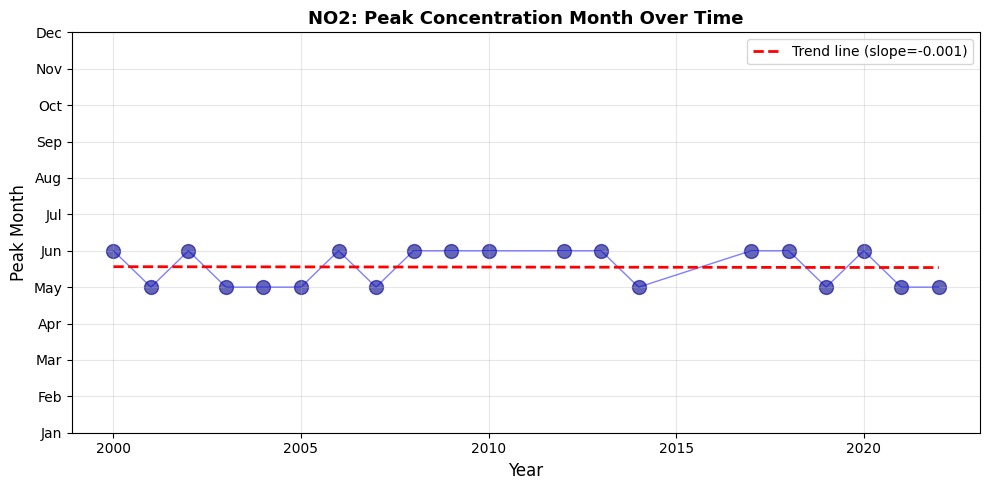


SO2:
----------------------------------------------------------------------
  Spearman correlation (Year vs Peak Month): -0.3146
  P-value: 0.1767
  CONCLUSION: No significant trend in peak timing over time


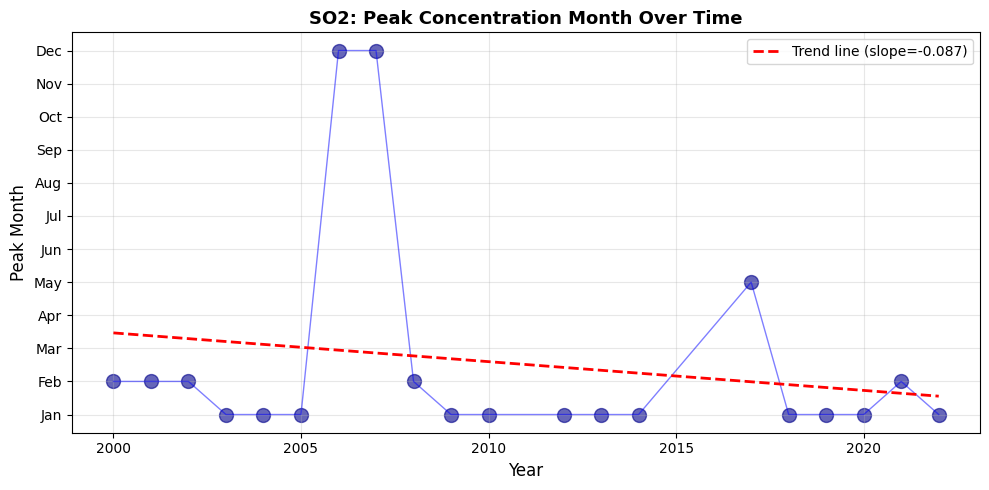


PM2.5:
----------------------------------------------------------------------
  Spearman correlation (Year vs Peak Month): -0.5473
  P-value: 0.0125
  CONCLUSION: Peak timing is significantly shifting EARLIER over time


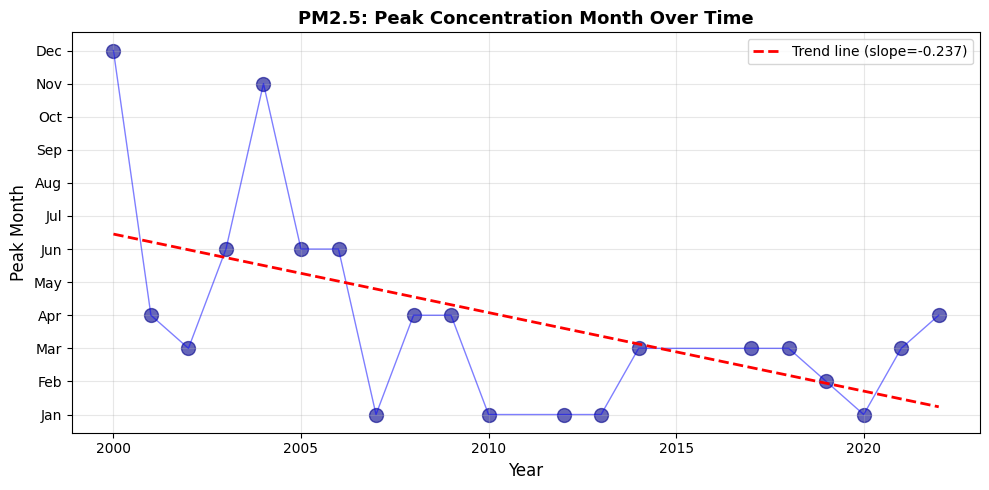


PM10:
----------------------------------------------------------------------
  Spearman correlation (Year vs Peak Month): -0.4311
  P-value: 0.0577
  CONCLUSION: No significant trend in peak timing over time


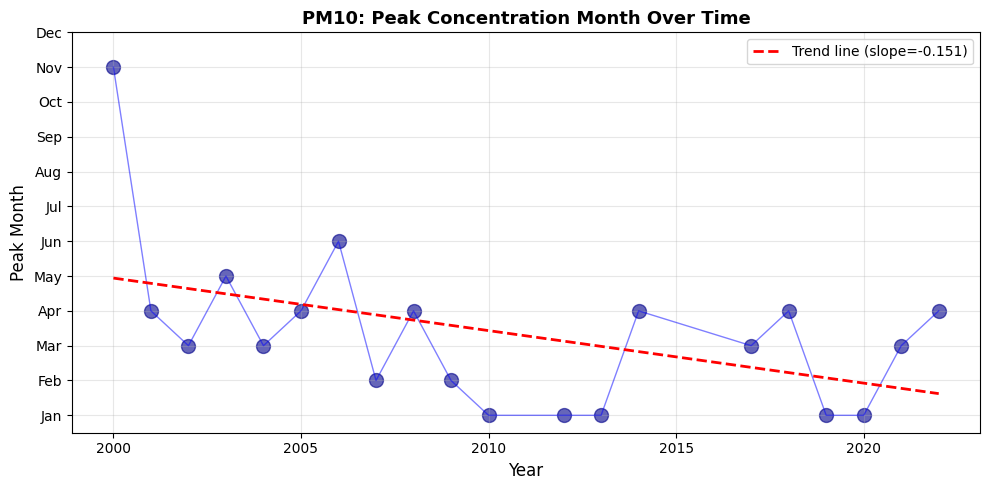

In [33]:
# Prepare data for monsoon-related pollutants
monsoon_pollutants = {
    'NO2': averaged_nitrogendioxide_df,
    'SO2': averaged_sulfurdioxide_df,
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare all pollutant dataframes
monsoon_dfs = {}
for name, series in monsoon_pollutants.items():
    monsoon_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods (e.g., early years vs recent years)
all_years = sorted(monsoon_dfs['PM2.5']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

print("="*70)
print("MONSOON SEASONALITY TIMING SHIFT ANALYSIS")
print("="*70)
print(f"\nEarly period: {early_years[0]}-{early_years[-1]}")
print(f"Recent period: {recent_years[0]}-{recent_years[-1]}")
print()

# Create comparison plots
fig, axes = plt.subplots(1, 4, figsize=(20, 6), dpi=100)

for idx, (pollutant_name, df) in enumerate(monsoon_dfs.items()):
    # Calculate monthly medians for early and recent periods
    early_data = df[df['Year'].isin(early_years)]
    recent_data = df[df['Year'].isin(recent_years)]
    
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    
    # Plot
    axes[idx].plot(early_monthly.index, early_monthly.values, 
                   marker='o', linewidth=2.5, label=f'Early ({early_years[0]}-{early_years[-1]})',
                   markersize=8, color='blue')
    axes[idx].plot(recent_monthly.index, recent_monthly.values, 
                   marker='s', linewidth=2.5, label=f'Recent ({recent_years[0]}-{recent_years[-1]})',
                   markersize=8, color='red')
    
    axes[idx].set_xlabel('Month', fontsize=11)
    axes[idx].set_ylabel(f'{pollutant_name} Concentration', fontsize=11)
    axes[idx].set_title(f'{pollutant_name} Seasonal Pattern Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis: Test if seasonal peak timing has shifted
print("="*70)
print("STATISTICAL TESTS FOR MONSOON TIMING SHIFTS")
print("="*70)
print()

def find_peak_month(df, pollutant_name, years):
    """Find the month with highest median concentration for given years"""
    year_data = df[df['Year'].isin(years)]
    monthly_median = year_data.groupby('Month')[pollutant_name].median()
    return monthly_median.idxmax()

def find_trough_month(df, pollutant_name, years):
    """Find the month with lowest median concentration for given years"""
    year_data = df[df['Year'].isin(years)]
    monthly_median = year_data.groupby('Month')[pollutant_name].median()
    return monthly_median.idxmin()

# Analyze peak and trough timing for each pollutant
for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{'='*70}")
    print(f"{pollutant_name} - PEAK AND TROUGH TIMING ANALYSIS")
    print(f"{'='*70}")
    
    # Find peaks for early and recent periods
    early_peak = find_peak_month(df, pollutant_name, early_years)
    recent_peak = find_peak_month(df, pollutant_name, recent_years)
    
    early_trough = find_trough_month(df, pollutant_name, early_years)
    recent_trough = find_trough_month(df, pollutant_name, recent_years)
    
    month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    print(f"\nPeak concentration month:")
    print(f"  Early period ({early_years[0]}-{early_years[-1]}): {month_names[early_peak]} (Month {early_peak})")
    print(f"  Recent period ({recent_years[0]}-{recent_years[-1]}): {month_names[recent_peak]} (Month {recent_peak})")
    print(f"  Shift: {recent_peak - early_peak} months {'later' if recent_peak > early_peak else 'earlier' if recent_peak < early_peak else '(no change)'}")
    
    print(f"\nTrough concentration month (monsoon effect):")
    print(f"  Early period ({early_years[0]}-{early_years[-1]}): {month_names[early_trough]} (Month {early_trough})")
    print(f"  Recent period ({recent_years[0]}-{recent_years[-1]}): {month_names[recent_trough]} (Month {recent_trough})")
    print(f"  Shift: {recent_trough - early_trough} months {'later' if recent_trough > early_trough else 'earlier' if recent_trough < early_trough else '(no change)'}")

# Test 2: Mann-Whitney U test comparing monthly distributions between periods
print("\n" + "="*70)
print("MANN-WHITNEY U TESTS: Early vs Recent Period by Month")
print("="*70)

for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    significant_months = []
    
    for month in range(1, 13):
        early_month_data = df[(df['Year'].isin(early_years)) & (df['Month'] == month)][pollutant_name]
        recent_month_data = df[(df['Year'].isin(recent_years)) & (df['Month'] == month)][pollutant_name]
        
        if len(early_month_data) > 0 and len(recent_month_data) > 0:
            u_stat, p_val = stats.mannwhitneyu(early_month_data, recent_month_data, alternative='two-sided')
            
            month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            
            if p_val < 0.05:
                significant_months.append(month_names[month])
                print(f"  {month_names[month]}: p = {p_val:.4f} * SIGNIFICANT")
            else:
                print(f"  {month_names[month]}: p = {p_val:.4f}")
    
    if significant_months:
        print(f"\n  Months with significant changes: {', '.join(significant_months)}")
    else:
        print(f"\n  No months show significant changes between periods")

# Test 3: Circular statistics for timing shift (advanced)
print("\n" + "="*70)
print("YEAR-BY-YEAR PEAK TIMING ANALYSIS")
print("="*70)

for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    peak_months_by_year = []
    years_list = []
    
    for year in all_years:
        year_data = df[df['Year'] == year]
        if len(year_data) > 0:
            monthly_median = year_data.groupby('Month')[pollutant_name].median()
            peak_month = monthly_median.idxmax()
            peak_months_by_year.append(peak_month)
            years_list.append(year)
    
    # Test correlation between year and peak month (is peak timing trending?)
    if len(years_list) > 2:
        corr, p_val = stats.spearmanr(years_list, peak_months_by_year)
        
        print(f"  Spearman correlation (Year vs Peak Month): {corr:.4f}")
        print(f"  P-value: {p_val:.4f}")
        
        if p_val < 0.05:
            if corr > 0:
                print(f"  CONCLUSION: Peak timing is significantly shifting LATER over time")
            else:
                print(f"  CONCLUSION: Peak timing is significantly shifting EARLIER over time")
        else:
            print(f"  CONCLUSION: No significant trend in peak timing over time")
        
        # Plot peak month over years
        plt.figure(figsize=(10, 5), dpi=100)
        plt.scatter(years_list, peak_months_by_year, s=100, alpha=0.6, color='darkblue')
        plt.plot(years_list, peak_months_by_year, linewidth=1, alpha=0.5, color='blue')
        
        # Add trend line
        z = np.polyfit(years_list, peak_months_by_year, 1)
        p = np.poly1d(z)
        plt.plot(years_list, p(years_list), "r--", linewidth=2, label=f'Trend line (slope={z[0]:.3f})')
        
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Peak Month', fontsize=12)
        plt.title(f'{pollutant_name}: Peak Concentration Month Over Time', fontsize=13, fontweight='bold')
        plt.yticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\n" + "="*70)

### Checking if there is significant change in peak duration

In [34]:
# import to create spline from medians
from scipy.interpolate import make_interp_spline

PEAK SEASON DURATION CHANGE ANALYSIS: EARLY vs RECENT

Early period: 2000-2009 (10 years)
Recent period: 2010-2022 (10 years)

FWHM ANALYSIS (Full Width at Half Maximum)

SO2:
----------------------------------------------------------------------
  Early period:  5 months (Jan, Feb, Mar, Nov, Dec)
  Recent period: 4 months (Jan, Feb, Mar, Dec)
  Change: -1 months (-20.0%)

NO2:
----------------------------------------------------------------------
  Early period:  7 months (Mar, Apr, May, Jun, Jul, Aug, Sep)
  Recent period: 7 months (Mar, Apr, May, Jun, Jul, Aug, Sep)
  Change: +0 months (+0.0%)

PM2.5:
----------------------------------------------------------------------
  Early period:  8 months (Jan, Feb, Mar, Apr, May, Jun, Nov, Dec)
  Recent period: 8 months (Jan, Feb, Mar, Apr, May, Jun, Nov, Dec)
  Change: +0 months (+0.0%)

PM10:
----------------------------------------------------------------------
  Early period:  8 months (Jan, Feb, Mar, Apr, May, Jun, Nov, Dec)
  Recent p

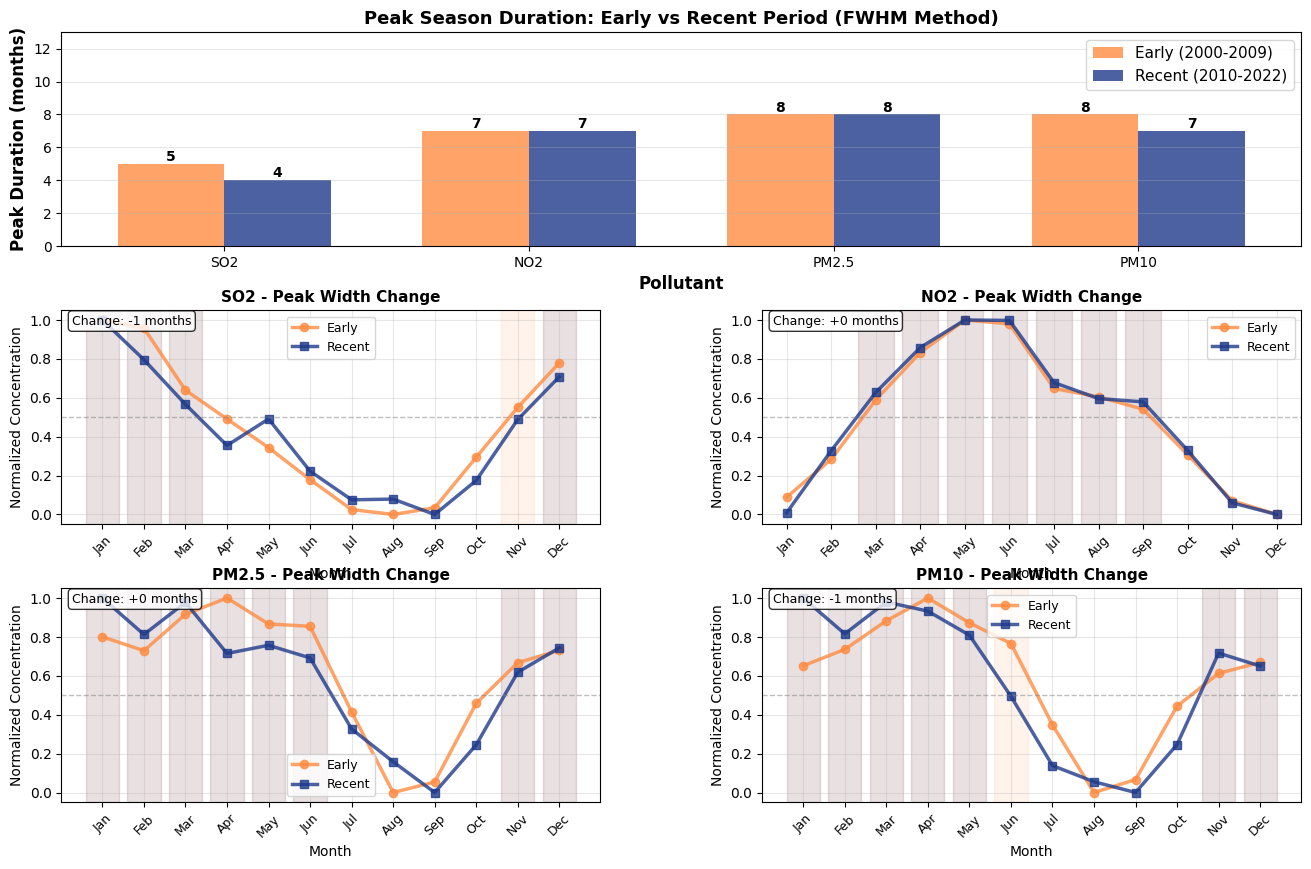

In [35]:
# Prepare data for all pollutants
all_pollutants = {
    'SO2': averaged_sulfurdioxide_df,
    'NO2': averaged_nitrogendioxide_df,
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare all pollutant dataframes
all_pollutant_dfs = {}
for name, series in all_pollutants.items():
    all_pollutant_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods
all_years = sorted(all_pollutant_dfs['PM2.5']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

print("="*70)
print("PEAK SEASON DURATION CHANGE ANALYSIS: EARLY vs RECENT")
print("="*70)
print(f"\nEarly period: {early_years[0]}-{early_years[-1]} ({len(early_years)} years)")
print(f"Recent period: {recent_years[0]}-{recent_years[-1]} ({len(recent_years)} years)")
print()

month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Method 1: FWHM (Full Width at Half Maximum)
def calculate_fwhm(monthly_medians):
    """
    Calculate Full Width at Half Maximum
    This measures the 'width' of the peak in the seasonal cycle
    """
    max_val = monthly_medians.max()
    min_val = monthly_medians.min()
    half_max = (max_val + min_val) / 2
    
    # Find months above half maximum
    above_half = monthly_medians >= half_max
    months_above = above_half[above_half].index.tolist()
    
    if len(months_above) == 0:
        return 0, []
    
    # Check if it wraps around (includes both Jan and Dec)
    if 1 in months_above and 12 in months_above:
        # Find gaps in the sequence
        all_months = set(range(1, 13))
        missing = sorted(all_months - set(months_above))
        if missing:
            width = 12 - len(missing)
        else:
            width = 12
    else:
        # Consecutive months
        width = max(months_above) - min(months_above) + 1
    
    return width, months_above

# Method 2: Top quartile count
def calculate_peak_quartile(monthly_medians):
    """
    Count months in top quartile (75th percentile)
    """
    q3 = monthly_medians.quantile(0.75)
    peak_months = monthly_medians[monthly_medians >= q3].index.tolist()
    return len(peak_months), peak_months

# Store results
results = {
    'early_fwhm': {},
    'recent_fwhm': {},
    'early_quartile': {},
    'recent_quartile': {},
    'early_months': {},
    'recent_months': {}
}

print("="*70)
print("FWHM ANALYSIS (Full Width at Half Maximum)")
print("="*70)

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_fwhm, early_months_fwhm = calculate_fwhm(early_monthly)
    results['early_fwhm'][pollutant_name] = early_fwhm
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_fwhm, recent_months_fwhm = calculate_fwhm(recent_monthly)
    results['recent_fwhm'][pollutant_name] = recent_fwhm
    
    # Change
    change_fwhm = recent_fwhm - early_fwhm
    pct_change = (change_fwhm / early_fwhm * 100) if early_fwhm > 0 else 0
    
    early_month_names = [month_names[m] for m in early_months_fwhm]
    recent_month_names = [month_names[m] for m in recent_months_fwhm]
    
    print(f"  Early period:  {early_fwhm} months ({', '.join(early_month_names)})")
    print(f"  Recent period: {recent_fwhm} months ({', '.join(recent_month_names)})")
    print(f"  Change: {change_fwhm:+d} months ({pct_change:+.1f}%)")

print("\n" + "="*70)
print("TOP QUARTILE ANALYSIS (75th Percentile)")
print("="*70)

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_quartile, early_months_q = calculate_peak_quartile(early_monthly)
    results['early_quartile'][pollutant_name] = early_quartile
    results['early_months'][pollutant_name] = early_months_q
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_quartile, recent_months_q = calculate_peak_quartile(recent_monthly)
    results['recent_quartile'][pollutant_name] = recent_quartile
    results['recent_months'][pollutant_name] = recent_months_q
    
    # Change
    change_quartile = recent_quartile - early_quartile
    pct_change = (change_quartile / early_quartile * 100) if early_quartile > 0 else 0
    
    early_month_names = [month_names[m] for m in early_months_q]
    recent_month_names = [month_names[m] for m in recent_months_q]
    
    print(f"  Early period:  {early_quartile} months ({', '.join(early_month_names)})")
    print(f"  Recent period: {recent_quartile} months ({', '.join(recent_month_names)})")
    print(f"  Change: {change_quartile:+d} months ({pct_change:+.1f}%)")

# Statistical tests for each pollutant
print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*70)
print("\nBootstrap Test: Are peak duration changes statistically significant?")
print()

np.random.seed(42)
n_bootstrap = 10000

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Bootstrap for early period
    early_data = df[df['Year'].isin(early_years)]
    early_fwhm_bootstrap = []
    
    for _ in range(n_bootstrap):
        # Resample months with replacement
        sample = early_data.sample(n=len(early_data), replace=True)
        monthly = sample.groupby('Month')[pollutant_name].median()
        fwhm, _ = calculate_fwhm(monthly)
        early_fwhm_bootstrap.append(fwhm)
    
    # Bootstrap for recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_fwhm_bootstrap = []
    
    for _ in range(n_bootstrap):
        sample = recent_data.sample(n=len(recent_data), replace=True)
        monthly = sample.groupby('Month')[pollutant_name].median()
        fwhm, _ = calculate_fwhm(monthly)
        recent_fwhm_bootstrap.append(fwhm)
    
    # Calculate observed difference
    observed_diff = results['recent_fwhm'][pollutant_name] - results['early_fwhm'][pollutant_name]
    
    # Calculate bootstrap differences
    bootstrap_diffs = np.array(recent_fwhm_bootstrap) - np.array(early_fwhm_bootstrap)
    
    # Calculate p-value (two-tailed)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    
    # Calculate confidence interval
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    print(f"  Observed change: {observed_diff:+d} months")
    print(f"  Bootstrap 95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"  P-value: {p_value:.4f}")
    print()
    
    if p_value < 0.05:
        print(f"  CONCLUSION: Peak duration change IS statistically significant (p < 0.05)")
        if observed_diff > 0:
            print(f"              Peak season has become LONGER in recent period")
        else:
            print(f"              Peak season has become SHORTER in recent period")
    else:
        print(f"  CONCLUSION: Peak duration change is NOT statistically significant (p ≥ 0.05)")

# Mann-Whitney U test comparing year-by-year durations
print("\n" + "="*70)
print("MANN-WHITNEY U TEST: Year-by-Year Duration Comparison")
print("="*70)
print()

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Calculate FWHM for each year
    early_yearly_fwhm = []
    for year in early_years:
        year_data = df[df['Year'] == year]
        if len(year_data) >= 6:  # Need sufficient data
            monthly = year_data.groupby('Month')[pollutant_name].median()
            fwhm, _ = calculate_fwhm(monthly)
            early_yearly_fwhm.append(fwhm)
    
    recent_yearly_fwhm = []
    for year in recent_years:
        year_data = df[df['Year'] == year]
        if len(year_data) >= 6:
            monthly = year_data.groupby('Month')[pollutant_name].median()
            fwhm, _ = calculate_fwhm(monthly)
            recent_yearly_fwhm.append(fwhm)
    
    # Perform Mann-Whitney U test
    if len(early_yearly_fwhm) > 0 and len(recent_yearly_fwhm) > 0:
        # Check if there's variation
        if len(set(early_yearly_fwhm + recent_yearly_fwhm)) == 1:
            print(f"  All years have identical duration: {early_yearly_fwhm[0]} months")
            print(f"  Statistical test not applicable (no variation)")
        else:
            u_stat, p_value = stats.mannwhitneyu(early_yearly_fwhm, recent_yearly_fwhm, 
                                                  alternative='two-sided')
            
            mean_early = np.mean(early_yearly_fwhm)
            mean_recent = np.mean(recent_yearly_fwhm)
            
            print(f"  Early period:  Mean = {mean_early:.2f} months (n={len(early_yearly_fwhm)} years)")
            print(f"  Recent period: Mean = {mean_recent:.2f} months (n={len(recent_yearly_fwhm)} years)")
            print(f"  Mann-Whitney U: {u_stat:.2f}")
            print(f"  P-value: {p_value:.4f}")
            print()
            
            if p_value < 0.05:
                print(f"  CONCLUSION: Significant difference between periods (p < 0.05)")
            else:
                print(f"  CONCLUSION: No significant difference between periods (p ≥ 0.05)")

# Visualization
fig = plt.figure(figsize=(16, 10), dpi=100)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Bar chart comparing early vs recent FWHM
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(all_pollutants))
width = 0.35

early_vals = [results['early_fwhm'][p] for p in all_pollutants.keys()]
recent_vals = [results['recent_fwhm'][p] for p in all_pollutants.keys()]

bars1 = ax1.bar(x - width/2, early_vals, width, label=f'Early ({early_years[0]}-{early_years[-1]})', 
                color='#FF8C42', alpha=0.8)
bars2 = ax1.bar(x + width/2, recent_vals, width, label=f'Recent ({recent_years[0]}-{recent_years[-1]})', 
                color='#1E3A8A', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Pollutant', fontsize=12, fontweight='bold')
ax1.set_ylabel('Peak Duration (months)', fontsize=12, fontweight='bold')
ax1.set_title('Peak Season Duration: Early vs Recent Period (FWHM Method)', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(all_pollutants.keys())
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 13)

# Plots 2-5: Seasonal patterns for each pollutant
for idx, (pollutant_name, df) in enumerate(all_pollutant_dfs.items()):
    ax = fig.add_subplot(gs[(idx//2)+1, idx%2])
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_norm = (early_monthly - early_monthly.min()) / (early_monthly.max() - early_monthly.min())
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_norm = (recent_monthly - recent_monthly.min()) / (recent_monthly.max() - recent_monthly.min())
    
    # Plot curves
    ax.plot(range(1, 13), early_norm.values, marker='o', linewidth=2.5, 
            color='#FF8C42', label='Early', alpha=0.8)
    ax.plot(range(1, 13), recent_norm.values, marker='s', linewidth=2.5, 
            color='#1E3A8A', label='Recent', alpha=0.8)
    
    # Shade FWHM regions
    _, early_months_fwhm = calculate_fwhm(early_monthly)
    _, recent_months_fwhm = calculate_fwhm(recent_monthly)
    
    for month in early_months_fwhm:
        ax.axvspan(month-0.4, month+0.4, alpha=0.1, color='#FF8C42')
    for month in recent_months_fwhm:
        ax.axvspan(month-0.4, month+0.4, alpha=0.1, color='#1E3A8A')
    
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Normalized Concentration', fontsize=10)
    ax.set_title(f'{pollutant_name} - Peak Width Change', fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names[1:], rotation=45, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add text showing change
    change = results['recent_fwhm'][pollutant_name] - results['early_fwhm'][pollutant_name]
    ax.text(0.02, 0.98, f'Change: {change:+d} months', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

print("\n" + "="*70)

### Checking both trough and peak durations

TROUGH SEASON DURATION CHANGE ANALYSIS: EARLY vs RECENT

Early period: 2000-2009 (10 years)
Recent period: 2010-2022 (10 years)

FWTM ANALYSIS (Full Width at Half Range - for Troughs)

SO2:
----------------------------------------------------------------------
  Early period:  7 months (Apr, May, Jun, Jul, Aug, Sep, Oct)
  Recent period: 8 months (Apr, May, Jun, Jul, Aug, Sep, Oct, Nov)
  Change: +1 months (+14.3%)

NO2:
----------------------------------------------------------------------
  Early period:  5 months (Jan, Feb, Oct, Nov, Dec)
  Recent period: 5 months (Jan, Feb, Oct, Nov, Dec)
  Change: +0 months (+0.0%)

PM2.5:
----------------------------------------------------------------------
  Early period:  4 months (Jul, Aug, Sep, Oct)
  Recent period: 4 months (Jul, Aug, Sep, Oct)
  Change: +0 months (+0.0%)

PM10:
----------------------------------------------------------------------
  Early period:  4 months (Jul, Aug, Sep, Oct)
  Recent period: 5 months (Jun, Jul, Aug, Sep,

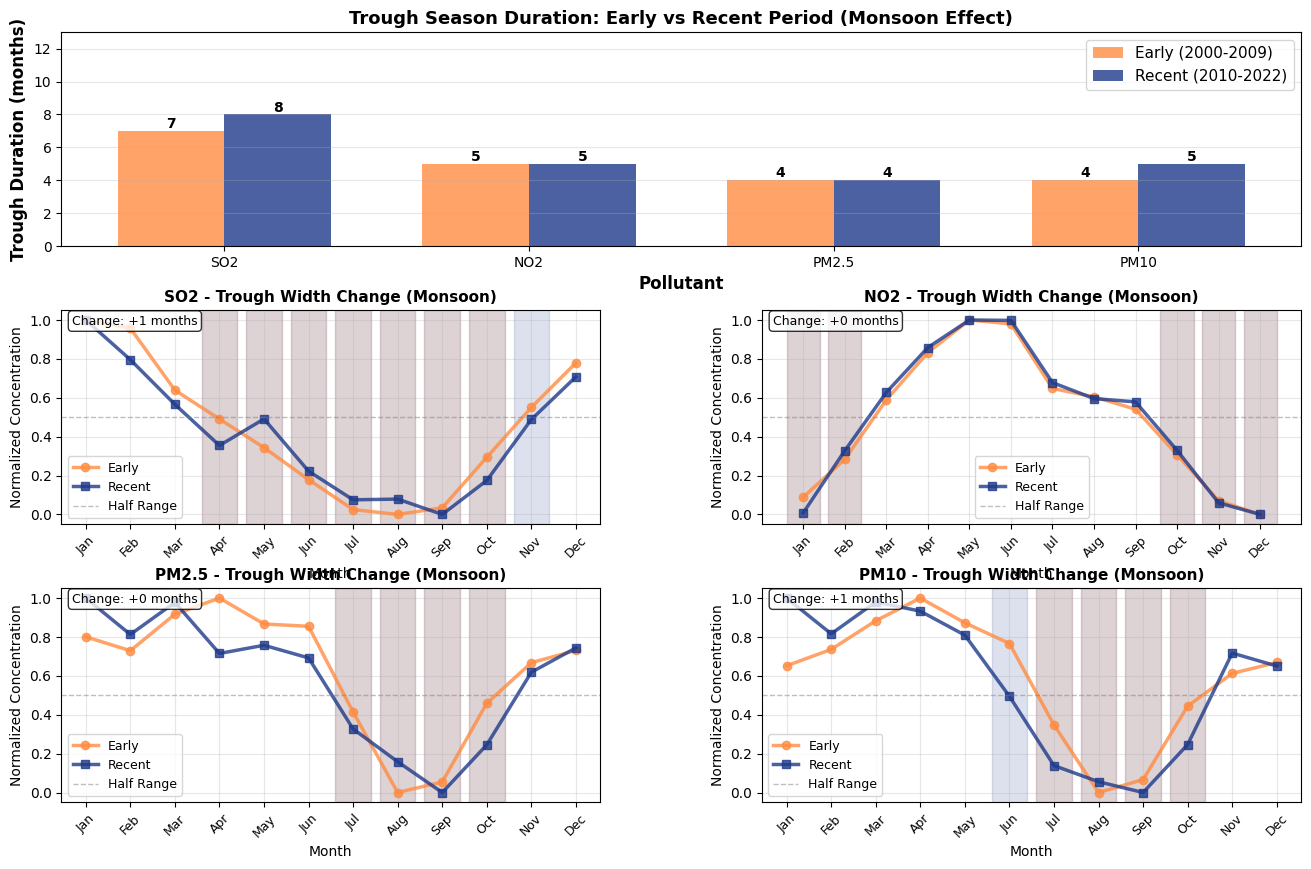

In [36]:
# Prepare data for all pollutants
all_pollutants = {
    'SO2': averaged_sulfurdioxide_df,
    'NO2': averaged_nitrogendioxide_df,
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare all pollutant dataframes
all_pollutant_dfs = {}
for name, series in all_pollutants.items():
    all_pollutant_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods
all_years = sorted(all_pollutant_dfs['PM2.5']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

print("="*70)
print("TROUGH SEASON DURATION CHANGE ANALYSIS: EARLY vs RECENT")
print("="*70)
print(f"\nEarly period: {early_years[0]}-{early_years[-1]} ({len(early_years)} years)")
print(f"Recent period: {recent_years[0]}-{recent_years[-1]} ({len(recent_years)} years)")
print()

month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Method 1: FWTM (Full Width at Third Maximum - inverted for troughs)
def calculate_fwtm(monthly_medians):
    """
    Calculate Full Width at Third Maximum (for troughs)
    This measures the 'width' of the trough/minimum in the seasonal cycle
    Uses the midpoint between min and max (similar to FWHM but inverted)
    """
    max_val = monthly_medians.max()
    min_val = monthly_medians.min()
    half_range = (max_val + min_val) / 2
    
    # Find months BELOW half range (trough months)
    below_half = monthly_medians <= half_range
    months_below = below_half[below_half].index.tolist()
    
    if len(months_below) == 0:
        return 0, []
    
    # Check if it wraps around (includes both Jan and Dec)
    if 1 in months_below and 12 in months_below:
        # Find gaps in the sequence
        all_months = set(range(1, 13))
        missing = sorted(all_months - set(months_below))
        if missing:
            width = 12 - len(missing)
        else:
            width = 12
    else:
        # Consecutive months
        width = max(months_below) - min(months_below) + 1
    
    return width, months_below

# Method 2: Bottom quartile count
def calculate_trough_quartile(monthly_medians):
    """
    Count months in bottom quartile (25th percentile)
    """
    q1 = monthly_medians.quantile(0.25)
    trough_months = monthly_medians[monthly_medians <= q1].index.tolist()
    return len(trough_months), trough_months

# Store results
results = {
    'early_fwtm': {},
    'recent_fwtm': {},
    'early_quartile': {},
    'recent_quartile': {},
    'early_months': {},
    'recent_months': {}
}

print("="*70)
print("FWTM ANALYSIS (Full Width at Half Range - for Troughs)")
print("="*70)

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_fwtm, early_months_fwtm = calculate_fwtm(early_monthly)
    results['early_fwtm'][pollutant_name] = early_fwtm
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_fwtm, recent_months_fwtm = calculate_fwtm(recent_monthly)
    results['recent_fwtm'][pollutant_name] = recent_fwtm
    
    # Change
    change_fwtm = recent_fwtm - early_fwtm
    pct_change = (change_fwtm / early_fwtm * 100) if early_fwtm > 0 else 0
    
    early_month_names = [month_names[m] for m in early_months_fwtm]
    recent_month_names = [month_names[m] for m in recent_months_fwtm]
    
    print(f"  Early period:  {early_fwtm} months ({', '.join(early_month_names)})")
    print(f"  Recent period: {recent_fwtm} months ({', '.join(recent_month_names)})")
    print(f"  Change: {change_fwtm:+d} months ({pct_change:+.1f}%)")

print("\n" + "="*70)
print("BOTTOM QUARTILE ANALYSIS (25th Percentile)")
print("="*70)

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_quartile, early_months_q = calculate_trough_quartile(early_monthly)
    results['early_quartile'][pollutant_name] = early_quartile
    results['early_months'][pollutant_name] = early_months_q
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_quartile, recent_months_q = calculate_trough_quartile(recent_monthly)
    results['recent_quartile'][pollutant_name] = recent_quartile
    results['recent_months'][pollutant_name] = recent_months_q
    
    # Change
    change_quartile = recent_quartile - early_quartile
    pct_change = (change_quartile / early_quartile * 100) if early_quartile > 0 else 0
    
    early_month_names = [month_names[m] for m in early_months_q]
    recent_month_names = [month_names[m] for m in recent_months_q]
    
    print(f"  Early period:  {early_quartile} months ({', '.join(early_month_names)})")
    print(f"  Recent period: {recent_quartile} months ({', '.join(recent_month_names)})")
    print(f"  Change: {change_quartile:+d} months ({pct_change:+.1f}%)")

# Statistical tests for each pollutant
print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*70)
print("\nBootstrap Test: Are trough duration changes statistically significant?")
print()

np.random.seed(42)
n_bootstrap = 10000

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Bootstrap for early period
    early_data = df[df['Year'].isin(early_years)]
    early_fwtm_bootstrap = []
    
    for _ in range(n_bootstrap):
        # Resample months with replacement
        sample = early_data.sample(n=len(early_data), replace=True)
        monthly = sample.groupby('Month')[pollutant_name].median()
        fwtm, _ = calculate_fwtm(monthly)
        early_fwtm_bootstrap.append(fwtm)
    
    # Bootstrap for recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_fwtm_bootstrap = []
    
    for _ in range(n_bootstrap):
        sample = recent_data.sample(n=len(recent_data), replace=True)
        monthly = sample.groupby('Month')[pollutant_name].median()
        fwtm, _ = calculate_fwtm(monthly)
        recent_fwtm_bootstrap.append(fwtm)
    
    # Calculate observed difference
    observed_diff = results['recent_fwtm'][pollutant_name] - results['early_fwtm'][pollutant_name]
    
    # Calculate bootstrap differences
    bootstrap_diffs = np.array(recent_fwtm_bootstrap) - np.array(early_fwtm_bootstrap)
    
    # Calculate p-value (two-tailed)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    
    # Calculate confidence interval
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    print(f"  Observed change: {observed_diff:+d} months")
    print(f"  Bootstrap 95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"  P-value: {p_value:.4f}")
    print()
    
    if p_value < 0.05:
        print(f"  CONCLUSION: Trough duration change IS statistically significant (p < 0.05)")
        if observed_diff > 0:
            print(f"              Trough season (monsoon) has become LONGER in recent period")
        else:
            print(f"              Trough season (monsoon) has become SHORTER in recent period")
    else:
        print(f"  CONCLUSION: Trough duration change is NOT statistically significant (p ≥ 0.05)")

# Mann-Whitney U test comparing year-by-year durations
print("\n" + "="*70)
print("MANN-WHITNEY U TEST: Year-by-Year Duration Comparison")
print("="*70)
print()

for pollutant_name, df in all_pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Calculate FWTM for each year
    early_yearly_fwtm = []
    for year in early_years:
        year_data = df[df['Year'] == year]
        if len(year_data) >= 6:  # Need sufficient data
            monthly = year_data.groupby('Month')[pollutant_name].median()
            fwtm, _ = calculate_fwtm(monthly)
            early_yearly_fwtm.append(fwtm)
    
    recent_yearly_fwtm = []
    for year in recent_years:
        year_data = df[df['Year'] == year]
        if len(year_data) >= 6:
            monthly = year_data.groupby('Month')[pollutant_name].median()
            fwtm, _ = calculate_fwtm(monthly)
            recent_yearly_fwtm.append(fwtm)
    
    # Perform Mann-Whitney U test
    if len(early_yearly_fwtm) > 0 and len(recent_yearly_fwtm) > 0:
        # Check if there's variation
        if len(set(early_yearly_fwtm + recent_yearly_fwtm)) == 1:
            print(f"  All years have identical duration: {early_yearly_fwtm[0]} months")
            print(f"  Statistical test not applicable (no variation)")
        else:
            u_stat, p_value = stats.mannwhitneyu(early_yearly_fwtm, recent_yearly_fwtm, 
                                                  alternative='two-sided')
            
            mean_early = np.mean(early_yearly_fwtm)
            mean_recent = np.mean(recent_yearly_fwtm)
            
            print(f"  Early period:  Mean = {mean_early:.2f} months (n={len(early_yearly_fwtm)} years)")
            print(f"  Recent period: Mean = {mean_recent:.2f} months (n={len(recent_yearly_fwtm)} years)")
            print(f"  Mann-Whitney U: {u_stat:.2f}")
            print(f"  P-value: {p_value:.4f}")
            print()
            
            if p_value < 0.05:
                print(f"  CONCLUSION: Significant difference between periods (p < 0.05)")
            else:
                print(f"  CONCLUSION: No significant difference between periods (p ≥ 0.05)")

# Visualization
fig = plt.figure(figsize=(16, 10), dpi=100)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Bar chart comparing early vs recent FWTM
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(all_pollutants))
width = 0.35

early_vals = [results['early_fwtm'][p] for p in all_pollutants.keys()]
recent_vals = [results['recent_fwtm'][p] for p in all_pollutants.keys()]

bars1 = ax1.bar(x - width/2, early_vals, width, label=f'Early ({early_years[0]}-{early_years[-1]})', 
                color='#FF8C42', alpha=0.8)
bars2 = ax1.bar(x + width/2, recent_vals, width, label=f'Recent ({recent_years[0]}-{recent_years[-1]})', 
                color='#1E3A8A', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Pollutant', fontsize=12, fontweight='bold')
ax1.set_ylabel('Trough Duration (months)', fontsize=12, fontweight='bold')
ax1.set_title('Trough Season Duration: Early vs Recent Period (Monsoon Effect)', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(all_pollutants.keys())
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 13)

# Plots 2-5: Seasonal patterns for each pollutant
for idx, (pollutant_name, df) in enumerate(all_pollutant_dfs.items()):
    ax = fig.add_subplot(gs[(idx//2)+1, idx%2])
    
    # Early period
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    early_norm = (early_monthly - early_monthly.min()) / (early_monthly.max() - early_monthly.min())
    
    # Recent period
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    recent_norm = (recent_monthly - recent_monthly.min()) / (recent_monthly.max() - recent_monthly.min())
    
    # Plot curves
    ax.plot(range(1, 13), early_norm.values, marker='o', linewidth=2.5, 
            color='#FF8C42', label='Early', alpha=0.8)
    ax.plot(range(1, 13), recent_norm.values, marker='s', linewidth=2.5, 
            color='#1E3A8A', label='Recent', alpha=0.8)
    
    # Shade FWTM regions (trough months)
    _, early_months_fwtm = calculate_fwtm(early_monthly)
    _, recent_months_fwtm = calculate_fwtm(recent_monthly)
    
    for month in early_months_fwtm:
        ax.axvspan(month-0.4, month+0.4, alpha=0.15, color='#FF8C42')
    for month in recent_months_fwtm:
        ax.axvspan(month-0.4, month+0.4, alpha=0.15, color='#1E3A8A')
    
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Half Range')
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Normalized Concentration', fontsize=10)
    ax.set_title(f'{pollutant_name} - Trough Width Change (Monsoon)', fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names[1:], rotation=45, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add text showing change
    change = results['recent_fwtm'][pollutant_name] - results['early_fwtm'][pollutant_name]
    ax.text(0.02, 0.98, f'Change: {change:+d} months', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

print("\n" + "="*70)

### Plotting shifts in peak and trough in early vs recent for pollutants with significant shifts

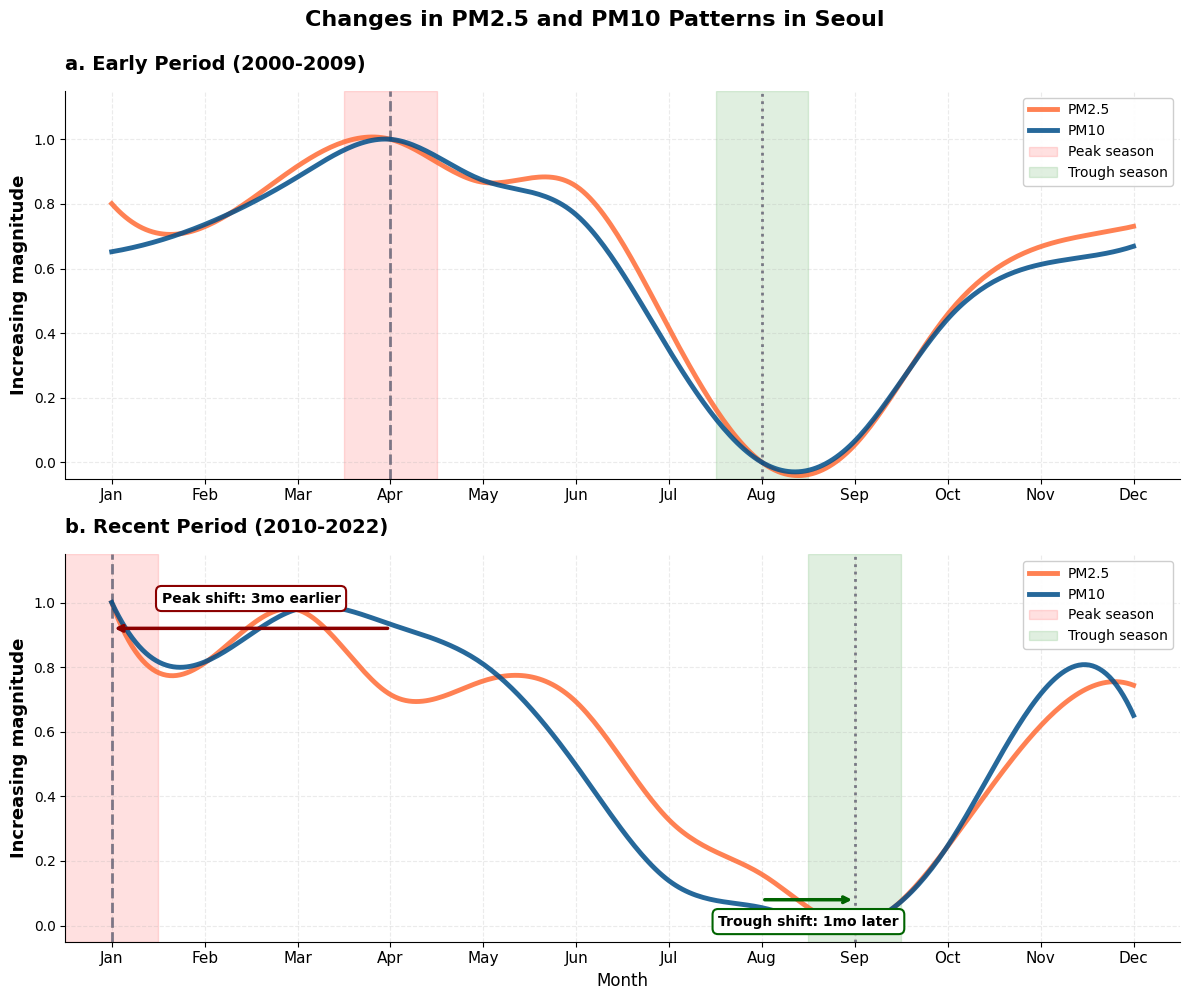

SEASONAL PATTERN SHIFT ANALYSIS: PM2.5 and PM10

Time periods:
  Early: 2000-2009
  Recent: 2010-2022

PM2.5:
----------------------------------------------------------------------
  Peak concentration:
    Early:  Apr (month 4)
    Recent: Jan (month 1)
    Shift:  -3 months
  Trough concentration (monsoon effect):
    Early:  Aug (month 8)
    Recent: Sep (month 9)
    Shift:  +1 months

PM10:
----------------------------------------------------------------------
  Peak concentration:
    Early:  Apr (month 4)
    Recent: Jan (month 1)
    Shift:  -3 months
  Trough concentration (monsoon effect):
    Early:  Aug (month 8)
    Recent: Sep (month 9)
    Shift:  +1 months



In [37]:
# Prepare data for PM pollutants
pollutants_to_plot = {
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare pollutant dataframes
pollutant_dfs = {}
for name, series in pollutants_to_plot.items():
    pollutant_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods
all_years = sorted(pollutant_dfs['PM2.5']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

# Create figure with two subplots (early and recent)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# Define colors for each pollutant
colors = {
    'PM2.5': '#FF6B35',  # Orange/red
    'PM10': '#004E89'     # Dark blue
}

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Store peak and trough information for annotations
peak_info = {'early': {}, 'recent': {}}
trough_info = {'early': {}, 'recent': {}}

# Plot 1: Early period
ax = axes[0]
for pollutant_name, df in pollutant_dfs.items():
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    
    # Normalize to 0-1 scale
    early_normalized = (early_monthly - early_monthly.min()) / (early_monthly.max() - early_monthly.min())
    
    # Create smooth curves
    months = np.array(range(1, 13))
    months_smooth = np.linspace(1, 12, 300)
    
    spline_early = make_interp_spline(months, early_normalized.values, k=3)
    early_smooth = spline_early(months_smooth)
    
    # Plot
    ax.plot(months_smooth, early_smooth, linewidth=3.5, 
            color=colors[pollutant_name], label=pollutant_name, alpha=0.85)
    
    # Store peak and trough information
    early_peak_month = early_monthly.idxmax()
    early_trough_month = early_monthly.idxmin()
    peak_info['early'][pollutant_name] = early_peak_month
    trough_info['early'][pollutant_name] = early_trough_month
    
    # Add vertical lines at peak and trough
    ax.axvline(early_peak_month, color=colors[pollutant_name], 
               linestyle='--', linewidth=2, alpha=0.5)
    ax.axvline(early_trough_month, color=colors[pollutant_name], 
               linestyle=':', linewidth=2, alpha=0.5)

# Add shaded regions for peak and trough seasons
peaks_early = list(peak_info['early'].values())
troughs_early = list(trough_info['early'].values())

if len(set(peaks_early)) > 1:
    ax.axvspan(min(peaks_early) - 0.5, max(peaks_early) + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season range')
else:
    ax.axvspan(peaks_early[0] - 0.5, peaks_early[0] + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season')

if len(set(troughs_early)) > 1:
    ax.axvspan(min(troughs_early) - 0.5, max(troughs_early) + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season range')
else:
    ax.axvspan(troughs_early[0] - 0.5, troughs_early[0] + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season')

# Formatting for early period plot

fig.suptitle('Changes in PM2.5 and PM10 Patterns in Seoul', fontsize=16, fontweight='bold', y=0.995)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=11)
ax.set_ylabel('Increasing magnitude', fontsize=13, fontweight='bold')
ax.set_title(f'a. Early Period ({early_years[0]}-{early_years[-1]})', 
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0.5, 12.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.25, linestyle='--')

# Plot 2: Recent period
ax = axes[1]
for pollutant_name, df in pollutant_dfs.items():
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    
    # Normalize to 0-1 scale
    recent_normalized = (recent_monthly - recent_monthly.min()) / (recent_monthly.max() - recent_monthly.min())
    
    # Create smooth curves
    months = np.array(range(1, 13))
    months_smooth = np.linspace(1, 12, 300)
    
    spline_recent = make_interp_spline(months, recent_normalized.values, k=3)
    recent_smooth = spline_recent(months_smooth)
    
    # Plot
    ax.plot(months_smooth, recent_smooth, linewidth=3.5, 
            color=colors[pollutant_name], label=pollutant_name, alpha=0.85)
    
    # Store peak and trough information
    recent_peak_month = recent_monthly.idxmax()
    recent_trough_month = recent_monthly.idxmin()
    peak_info['recent'][pollutant_name] = recent_peak_month
    trough_info['recent'][pollutant_name] = recent_trough_month
    
    # Add vertical lines at peak and trough
    ax.axvline(recent_peak_month, color=colors[pollutant_name], 
               linestyle='--', linewidth=2, alpha=0.5)
    ax.axvline(recent_trough_month, color=colors[pollutant_name], 
               linestyle=':', linewidth=2, alpha=0.5)

# Add shaded regions
peaks_recent = list(peak_info['recent'].values())
troughs_recent = list(trough_info['recent'].values())

if len(set(peaks_recent)) > 1:
    ax.axvspan(min(peaks_recent) - 0.5, max(peaks_recent) + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season range')
else:
    ax.axvspan(peaks_recent[0] - 0.5, peaks_recent[0] + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season')

if len(set(troughs_recent)) > 1:
    ax.axvspan(min(troughs_recent) - 0.5, max(troughs_recent) + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season range')
else:
    ax.axvspan(troughs_recent[0] - 0.5, troughs_recent[0] + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season')

# Add arrows showing shifts for both peak and trough
avg_early_peak = np.mean(peaks_early)
avg_recent_peak = np.mean(peaks_recent)
avg_early_trough = np.mean(troughs_early)
avg_recent_trough = np.mean(troughs_recent)

# Peak shift arrow
if abs(avg_recent_peak - avg_early_peak) > 0.5:
    arrow_y_peak = 0.92
    ax.annotate('', xy=(avg_recent_peak, arrow_y_peak), 
                xytext=(avg_early_peak, arrow_y_peak),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='darkred'))
    
    shift_months = int(round(avg_recent_peak - avg_early_peak))
    shift_text = f'Peak shift: {abs(shift_months)}mo {"later" if shift_months > 0 else "earlier"}'
    ax.text((avg_early_peak + avg_recent_peak) / 2, arrow_y_peak + 0.08, 
            shift_text, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                     edgecolor='darkred', linewidth=1.5))

# Trough shift arrow
if abs(avg_recent_trough - avg_early_trough) > 0.5:
    arrow_y_trough = 0.08
    ax.annotate('', xy=(avg_recent_trough, arrow_y_trough), 
                xytext=(avg_early_trough, arrow_y_trough),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='darkgreen'))
    
    shift_months = int(round(avg_recent_trough - avg_early_trough))
    shift_text = f'Trough shift: {abs(shift_months)}mo {"later" if shift_months > 0 else "earlier"}'
    ax.text((avg_early_trough + avg_recent_trough) / 2, arrow_y_trough - 0.08, 
            shift_text, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                     edgecolor='darkgreen', linewidth=1.5))

# Formatting for recent period plot
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=11)
ax.set_ylabel('Increasing magnitude', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_title(f'b. Recent Period ({recent_years[0]}-{recent_years[-1]})', 
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0.5, 12.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

# Print statistical summary
print("="*70)
print("SEASONAL PATTERN SHIFT ANALYSIS: PM2.5 and PM10")
print("="*70)
print(f"\nTime periods:")
print(f"  Early: {early_years[0]}-{early_years[-1]}")
print(f"  Recent: {recent_years[0]}-{recent_years[-1]}")
print()

for pollutant_name, df in pollutant_dfs.items():
    print(f"{pollutant_name}:")
    print("-"*70)
    
    early_data = df[df['Year'].isin(early_years)]
    recent_data = df[df['Year'].isin(recent_years)]
    
    early_monthly = early_data.groupby('Month')[pollutant_name].median()
    recent_monthly = recent_data.groupby('Month')[pollutant_name].median()
    
    early_peak = early_monthly.idxmax()
    recent_peak = recent_monthly.idxmax()
    early_trough = early_monthly.idxmin()
    recent_trough = recent_monthly.idxmin()
    
    print(f"  Peak concentration:")
    print(f"    Early:  {month_names[early_peak-1]} (month {early_peak})")
    print(f"    Recent: {month_names[recent_peak-1]} (month {recent_peak})")
    print(f"    Shift:  {recent_peak - early_peak:+d} months")
    
    print(f"  Trough concentration (monsoon effect):")
    print(f"    Early:  {month_names[early_trough-1]} (month {early_trough})")
    print(f"    Recent: {month_names[recent_trough-1]} (month {recent_trough})")
    print(f"    Shift:  {recent_trough - early_trough:+d} months")
    print()

print("="*70)

### Area Under the Curve change analysis for PM2.5 and PM10

In [38]:
from scipy.integrate import simpson

# Prepare data for PM pollutants
pollutants_to_plot = {
    'PM2.5': averaged_pm25_df,
    'PM10': averaged_pm10_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.to_frame(name=pollutant_name)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare pollutant dataframes
pollutant_dfs = {}
for name, series in pollutants_to_plot.items():
    pollutant_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods
all_years = sorted(pollutant_dfs['PM2.5']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

print("="*70)
print("AUC ANALYSIS: PEAK TO TROUGH POLLUTANT EXPOSURE")
print("="*70)
print(f"\nTime periods:")
print(f"  Early: {early_years[0]}-{early_years[-1]}")
print(f"  Recent: {recent_years[0]}-{recent_years[-1]}")
print()

month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate AUC for each pollutant between peak and trough
for pollutant_name, df in pollutant_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    # Get early and recent period data
    early_data = df[df['Year'].isin(early_years)]
    recent_data = df[df['Year'].isin(recent_years)]
    
    # Calculate monthly means
    early_monthly = early_data.groupby('Month')[pollutant_name].mean()
    recent_monthly = recent_data.groupby('Month')[pollutant_name].mean()
    
    # Find peak and trough months
    early_peak = early_monthly.idxmax()
    early_trough = early_monthly.idxmin()
    recent_peak = recent_monthly.idxmax()
    recent_trough = recent_monthly.idxmin()
    
    print(f"\n  Early Period:")
    print(f"    Peak: {month_names[early_peak]} (month {early_peak})")
    print(f"    Trough: {month_names[early_trough]} (month {early_trough})")
    
    print(f"\n  Recent Period:")
    print(f"    Peak: {month_names[recent_peak]} (month {recent_peak})")
    print(f"    Trough: {month_names[recent_trough]} (month {recent_trough})")
    
    # Extract months between peak and trough (inclusive)
    # Handle wrap-around if trough comes before peak in calendar
    if early_peak < early_trough:
        early_months_range = list(range(early_peak, early_trough + 1))
    else:
        # Wrap around year (e.g., Dec to Jun)
        early_months_range = list(range(early_peak, 13)) + list(range(1, early_trough + 1))
    
    if recent_peak < recent_trough:
        recent_months_range = list(range(recent_peak, recent_trough + 1))
    else:
        recent_months_range = list(range(recent_peak, 13)) + list(range(1, recent_trough + 1))
    
    # Get values for those months
    early_values = early_monthly[early_months_range].values
    recent_values = recent_monthly[recent_months_range].values
    
    # Calculate AUC using trapezoidal rule
    early_auc = np.trapz(early_values, x=np.arange(len(early_values)))
    recent_auc = np.trapz(recent_values, x=np.arange(len(recent_values)))
    
    # Calculate percentage change
    auc_change = recent_auc - early_auc
    percent_change = (auc_change / early_auc) * 100
    
    print(f"\n  Area Under Curve (Peak to Trough):")
    print(f"    Early AUC:   {early_auc:.2f}")
    print(f"    Recent AUC:  {recent_auc:.2f}")
    print(f"    Change:      {auc_change:+.2f} ({percent_change:+.1f}%)")
    
    if percent_change < 0:
        print(f"    → {abs(percent_change):.1f}% REDUCTION in cumulative exposure from peak to trough")
    else:
        print(f"    → {percent_change:.1f}% INCREASE in cumulative exposure from peak to trough")

print("\n" + "="*70)

AUC ANALYSIS: PEAK TO TROUGH POLLUTANT EXPOSURE

Time periods:
  Early: 2000-2009
  Recent: 2010-2022


PM2.5:
----------------------------------------------------------------------

  Early Period:
    Peak: Apr (month 4)
    Trough: Aug (month 8)

  Recent Period:
    Peak: Jan (month 1)
    Trough: Sep (month 9)

  Area Under Curve (Peak to Trough):
    Early AUC:   117.66
    Recent AUC:  177.34
    Change:      +59.68 (+50.7%)
    → 50.7% INCREASE in cumulative exposure from peak to trough

PM10:
----------------------------------------------------------------------

  Early Period:
    Peak: Apr (month 4)
    Trough: Aug (month 8)

  Recent Period:
    Peak: Mar (month 3)
    Trough: Sep (month 9)

  Area Under Curve (Peak to Trough):
    Early AUC:   226.93
    Recent AUC:  222.59
    Change:      -4.34 (-1.9%)
    → 1.9% REDUCTION in cumulative exposure from peak to trough



## Seoul Precipitation

In [39]:
precip_df = pd.read_csv('C:/Users/beane/Documents/Code/ENVS Final/Data/Seoul_Precipitation/4177382.csv')
display(precip_df)


,STATION,NAME,DATE,PRCP
0,KS000047112,"INCHEON, KS",1988-01-01,0.08
1,KS000047112,"INCHEON, KS",1988-01-02,0.00
2,KS000047112,"INCHEON, KS",1988-01-03,0.00
3,KS000047112,"INCHEON, KS",1988-01-04,0.00
4,KS000047112,"INCHEON, KS",1988-01-05,0.00
...,...,...,...,...
27464,KSM00047108,"SEOUL CITY, KS",2025-08-20,NaN
27465,KSM00047108,"SEOUL CITY, KS",2025-08-21,NaN
27466,KSM00047108,"SEOUL CITY, KS",2025-08-22,NaN
27467,KSM00047108,"SEOUL CITY, KS",2025-08-23,NaN


In [40]:
# Remove NaN values
precip_df = precip_df.dropna(subset=['PRCP'])
display(precip_df)

,STATION,NAME,DATE,PRCP
0,KS000047112,"INCHEON, KS",1988-01-01,0.08
1,KS000047112,"INCHEON, KS",1988-01-02,0.00
2,KS000047112,"INCHEON, KS",1988-01-03,0.00
3,KS000047112,"INCHEON, KS",1988-01-04,0.00
4,KS000047112,"INCHEON, KS",1988-01-05,0.00
...,...,...,...,...
27130,KSM00047108,"SEOUL CITY, KS",2024-09-15,0.00
27236,KSM00047108,"SEOUL CITY, KS",2025-01-04,0.01
27237,KSM00047108,"SEOUL CITY, KS",2025-01-05,0.37
27238,KSM00047108,"SEOUL CITY, KS",2025-01-06,0.07


In [42]:
# Convert date column into datetime
precip_df['DATE'] = pd.to_datetime(precip_df['DATE'])
display(precip_df)
precip_df.info()

,STATION,NAME,DATE,PRCP
0,KS000047112,"INCHEON, KS",1988-01-01,0.08
1,KS000047112,"INCHEON, KS",1988-01-02,0.00
2,KS000047112,"INCHEON, KS",1988-01-03,0.00
3,KS000047112,"INCHEON, KS",1988-01-04,0.00
4,KS000047112,"INCHEON, KS",1988-01-05,0.00
...,...,...,...,...
27130,KSM00047108,"SEOUL CITY, KS",2024-09-15,0.00
27236,KSM00047108,"SEOUL CITY, KS",2025-01-04,0.01
27237,KSM00047108,"SEOUL CITY, KS",2025-01-05,0.37
27238,KSM00047108,"SEOUL CITY, KS",2025-01-06,0.07


<class 'pandas.core.frame.DataFrame'>
Index: 12077 entries, 0 to 27239
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  12077 non-null  object        
 1   NAME     12077 non-null  object        
 2   DATE     12077 non-null  datetime64[ns]
 3   PRCP     12077 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 471.8+ KB


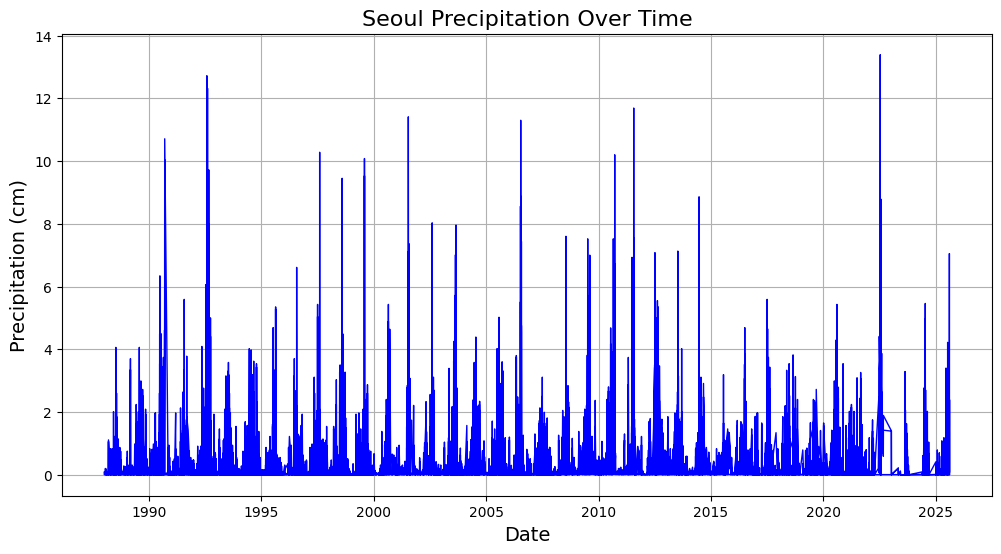

In [43]:
# Plot time series of precipitation
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(precip_df['DATE'], precip_df['PRCP'], color='blue', linewidth=1)
plt.title('Seoul Precipitation Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Precipitation (cm)', fontsize=14)
plt.grid(True)
plt.show()

### Comparing shift in means

MONSOON SEASONALITY TIMING SHIFT ANALYSIS

Early period: 1988-2006
Recent period: 2007-2025



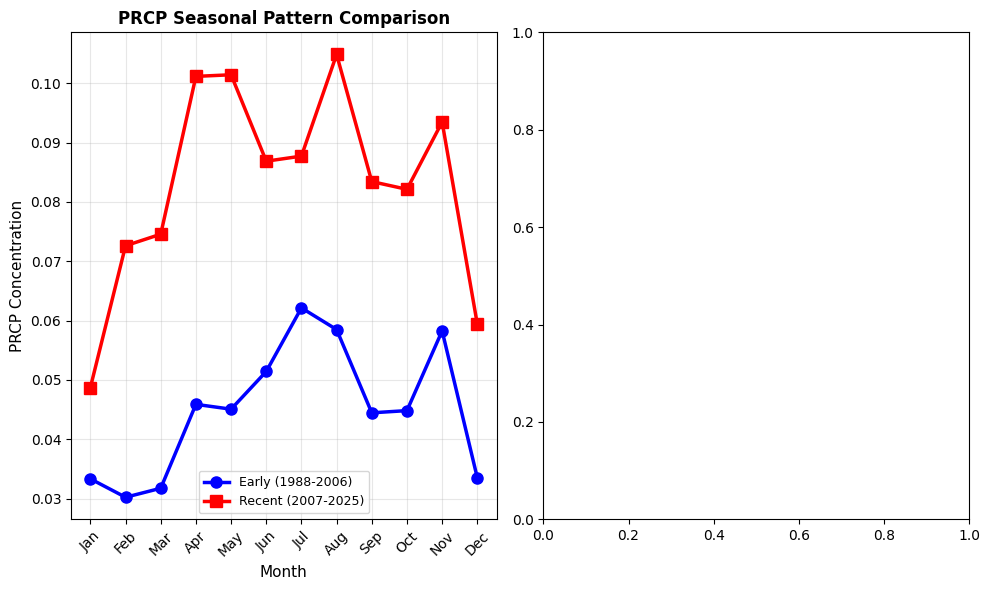

STATISTICAL TESTS FOR MONSOON TIMING SHIFTS


PRCP - PEAK AND TROUGH TIMING ANALYSIS

Peak concentration month:
  Early period (1988-2006): Jul (Month 7)
  Recent period (2007-2025): Aug (Month 8)
  Shift: 1 months later

Trough concentration month (monsoon effect):
  Early period (1988-2006): Feb (Month 2)
  Recent period (2007-2025): Jan (Month 1)
  Shift: -1 months earlier

MANN-WHITNEY U TESTS: Early vs Recent Period by Month

PRCP:
----------------------------------------------------------------------
  Jan: p = 0.0000 * SIGNIFICANT
  Feb: p = 0.0000 * SIGNIFICANT
  Mar: p = 0.0000 * SIGNIFICANT
  Apr: p = 0.0000 * SIGNIFICANT
  May: p = 0.0000 * SIGNIFICANT
  Jun: p = 0.0000 * SIGNIFICANT
  Jul: p = 0.0000 * SIGNIFICANT
  Aug: p = 0.0000 * SIGNIFICANT
  Sep: p = 0.0000 * SIGNIFICANT
  Oct: p = 0.0000 * SIGNIFICANT
  Nov: p = 0.0000 * SIGNIFICANT
  Dec: p = 0.0000 * SIGNIFICANT

  Months with significant changes: Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec

YEAR-BY-

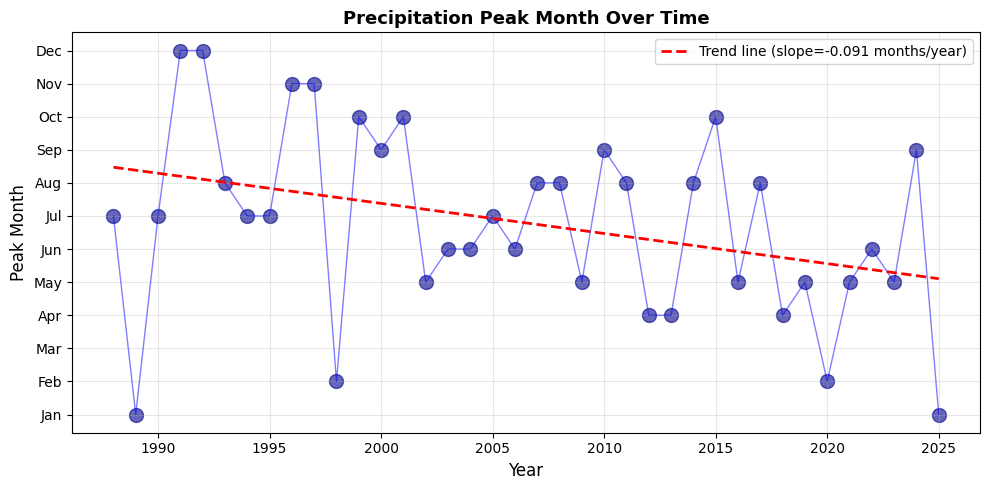

In [44]:
# Run significance test on monthly mean and yearly mean trends

# Prepare data for monsoon-related pollutants
monsoon_pollutants = {
    'PRCP': precip_df,
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.copy()

    # Convert DATE to datetime and set as index if not already
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.set_index('DATE', inplace=True)

    # Add month and year columns for grouping
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare all pollutant dataframes
monsoon_dfs = {}
for name, series in monsoon_pollutants.items():
    monsoon_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods (e.g., early years vs recent years)
all_years = sorted(monsoon_dfs['PRCP']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

print("="*70)
print("MONSOON SEASONALITY TIMING SHIFT ANALYSIS")
print("="*70)
print(f"\nEarly period: {early_years[0]}-{early_years[-1]}")
print(f"Recent period: {recent_years[0]}-{recent_years[-1]}")
print()

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=100)

for idx, (pollutant_name, df) in enumerate(monsoon_dfs.items()):
    # Calculate monthly means for early and recent periods
    early_data = df[df['Year'].isin(early_years)]
    recent_data = df[df['Year'].isin(recent_years)]
    
    early_monthly = early_data.groupby('Month')[pollutant_name].mean()
    recent_monthly = recent_data.groupby('Month')[pollutant_name].mean()
    
    # Plot
    axes[idx].plot(early_monthly.index, early_monthly.values, 
                   marker='o', linewidth=2.5, label=f'Early ({early_years[0]}-{early_years[-1]})',
                   markersize=8, color='blue')
    axes[idx].plot(recent_monthly.index, recent_monthly.values, 
                   marker='s', linewidth=2.5, label=f'Recent ({recent_years[0]}-{recent_years[-1]})',
                   markersize=8, color='red')
    
    axes[idx].set_xlabel('Month', fontsize=11)
    axes[idx].set_ylabel(f'{pollutant_name} Concentration', fontsize=11)
    axes[idx].set_title(f'{pollutant_name} Seasonal Pattern Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis: Test if seasonal peak timing has shifted
print("="*70)
print("STATISTICAL TESTS FOR MONSOON TIMING SHIFTS")
print("="*70)
print()

def find_peak_month(df, pollutant_name, years):
    """Find the month with highest mean concentration for given years"""
    year_data = df[df['Year'].isin(years)]
    monthly_mean = year_data.groupby('Month')[pollutant_name].mean()
    return monthly_mean.idxmax()

def find_trough_month(df, pollutant_name, years):
    """Find the month with lowest mean concentration for given years"""
    year_data = df[df['Year'].isin(years)]
    monthly_mean = year_data.groupby('Month')[pollutant_name].mean()
    return monthly_mean.idxmin()

# Analyze peak and trough timing for each pollutant
for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{'='*70}")
    print(f"{pollutant_name} - PEAK AND TROUGH TIMING ANALYSIS")
    print(f"{'='*70}")
    
    # Find peaks for early and recent periods
    early_peak = find_peak_month(df, pollutant_name, early_years)
    recent_peak = find_peak_month(df, pollutant_name, recent_years)
    
    early_trough = find_trough_month(df, pollutant_name, early_years)
    recent_trough = find_trough_month(df, pollutant_name, recent_years)
    
    month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    print(f"\nPeak concentration month:")
    print(f"  Early period ({early_years[0]}-{early_years[-1]}): {month_names[early_peak]} (Month {early_peak})")
    print(f"  Recent period ({recent_years[0]}-{recent_years[-1]}): {month_names[recent_peak]} (Month {recent_peak})")
    print(f"  Shift: {recent_peak - early_peak} months {'later' if recent_peak > early_peak else 'earlier' if recent_peak < early_peak else '(no change)'}")
    
    print(f"\nTrough concentration month (monsoon effect):")
    print(f"  Early period ({early_years[0]}-{early_years[-1]}): {month_names[early_trough]} (Month {early_trough})")
    print(f"  Recent period ({recent_years[0]}-{recent_years[-1]}): {month_names[recent_trough]} (Month {recent_trough})")
    print(f"  Shift: {recent_trough - early_trough} months {'later' if recent_trough > early_trough else 'earlier' if recent_trough < early_trough else '(no change)'}")

# Test 2: Mann-Whitney U test comparing monthly distributions between periods
print("\n" + "="*70)
print("MANN-WHITNEY U TESTS: Early vs Recent Period by Month")
print("="*70)

for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    significant_months = []
    
    for month in range(1, 13):
        early_month_data = df[(df['Year'].isin(early_years)) & (df['Month'] == month)][pollutant_name]
        recent_month_data = df[(df['Year'].isin(recent_years)) & (df['Month'] == month)][pollutant_name]
        
        if len(early_month_data) > 0 and len(recent_month_data) > 0:
            u_stat, p_val = stats.mannwhitneyu(early_month_data, recent_month_data, alternative='two-sided')
            
            month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            
            if p_val < 0.05:
                significant_months.append(month_names[month])
                print(f"  {month_names[month]}: p = {p_val:.4f} * SIGNIFICANT")
            else:
                print(f"  {month_names[month]}: p = {p_val:.4f}")
    
    if significant_months:
        print(f"\n  Months with significant changes: {', '.join(significant_months)}")
    else:
        print(f"\n  No months show significant changes between periods")

# Test 3: Circular statistics for timing shift (advanced)
print("\n" + "="*70)
print("YEAR-BY-YEAR PEAK TIMING ANALYSIS")
print("="*70)

for pollutant_name, df in monsoon_dfs.items():
    print(f"\n{pollutant_name}:")
    print("-"*70)
    
    peak_months_by_year = []
    years_list = []
    
    for year in all_years:
        year_data = df[df['Year'] == year]
        if len(year_data) > 0:
            monthly_mean = year_data.groupby('Month')[pollutant_name].mean()
            peak_month = monthly_mean.idxmax()
            peak_months_by_year.append(peak_month)
            years_list.append(year)
    
    # Test correlation between year and peak month (is peak timing trending?)
    if len(years_list) > 2:
        corr, p_val = stats.spearmanr(years_list, peak_months_by_year)
        
        print(f"  Spearman correlation (Year vs Peak Month): {corr:.4f}")
        print(f"  P-value: {p_val:.4f}")
        
        if p_val < 0.05:
            if corr > 0:
                print(f"  CONCLUSION: Peak timing is significantly shifting LATER over time")
            else:
                print(f"  CONCLUSION: Peak timing is significantly shifting EARLIER over time")
        else:
            print(f"  CONCLUSION: No significant trend in peak timing over time")
        
        # Plot peak month over years
        plt.figure(figsize=(10, 5), dpi=100)
        plt.scatter(years_list, peak_months_by_year, s=100, alpha=0.6, color='darkblue')
        plt.plot(years_list, peak_months_by_year, linewidth=1, alpha=0.5, color='blue')
        
        # Add trend line
        z = np.polyfit(years_list, peak_months_by_year, 1)
        p = np.poly1d(z)
        plt.plot(years_list, p(years_list), "r--", linewidth=2, label=f'Trend line (slope={z[0]:.3f} months/year)')
        
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Peak Month', fontsize=12)
        plt.title('Precipitation Peak Month Over Time', fontsize=13, fontweight='bold')
        plt.yticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\n" + "="*70)

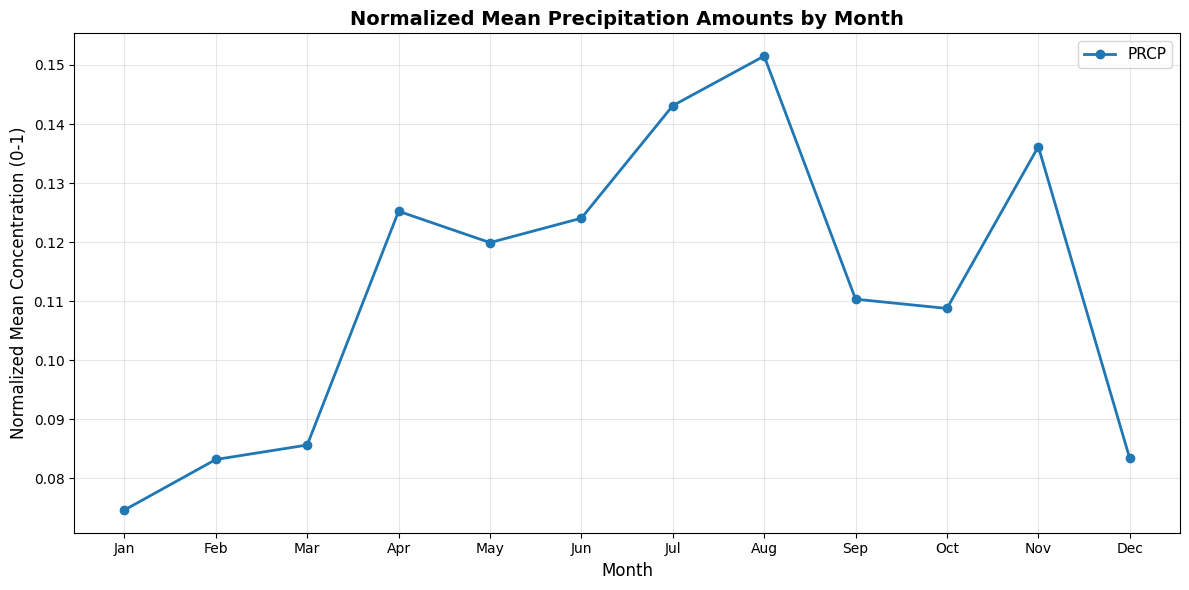

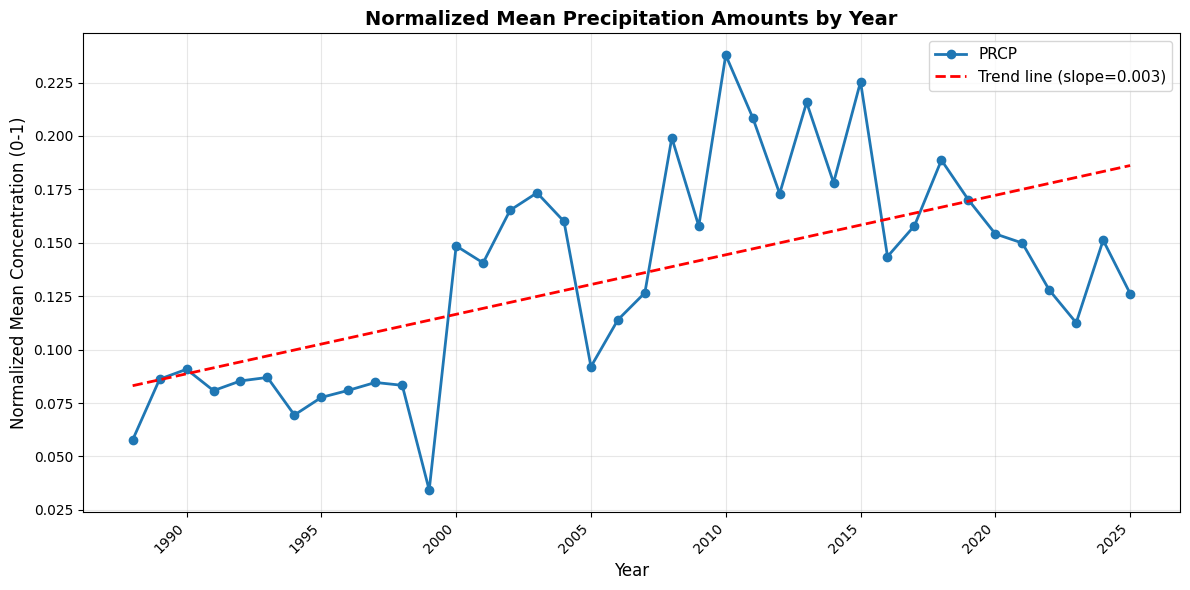

In [45]:
# Line graph of the means monthly & over time
# Prepare data for all pollutants
pollutants = {
    'PRCP': precip_df
}

# Function to prepare dataframe, remove outliers, and normalize
def prepare_and_normalize_pollutant_data(series, pollutant_name):
    df = series.copy()

    # Convert DATE to datetime and set as index if not already
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.set_index('DATE', inplace=True)

    # Add month and year columns for grouping
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Step 1: Remove outliers FIRST
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    
    # Step 2: Normalize AFTER removing outliers (min-max scaling to 0-1)
    min_val = df_filtered[pollutant_name].min()
    max_val = df_filtered[pollutant_name].max()
    df_filtered[f'{pollutant_name}_normalized'] = (df_filtered[pollutant_name] - min_val) / (max_val - min_val)
    
    return df_filtered

# Prepare all pollutant dataframes
pollutant_dfs = {}
for name, series in pollutants.items():
    pollutant_dfs[name] = prepare_and_normalize_pollutant_data(series, name)

# Plot 1: Normalized Mean by Month
plt.figure(figsize=(12, 6), dpi=100)
for pollutant_name, df in pollutant_dfs.items():
    monthly_means = df.groupby('Month')[f'{pollutant_name}_normalized'].mean()
    plt.plot(monthly_means.index, monthly_means.values, 
             marker='o', linewidth=2, label=pollutant_name, markersize=6)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Normalized Mean Concentration (0-1)', fontsize=12)
plt.title('Normalized Mean Precipitation Amounts by Month', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Normalized Mean by Year
plt.figure(figsize=(12, 6), dpi=100)
for pollutant_name, df in pollutant_dfs.items():
    yearly_means = df.groupby('Year')[f'{pollutant_name}_normalized'].mean()
    plt.plot(yearly_means.index, yearly_means.values, 
             marker='o', linewidth=2, label=pollutant_name, markersize=6)
    
z = np.polyfit(years_list, yearly_means, 1)
p = np.poly1d(z)
plt.plot(years_list, p(years_list), "r--", linewidth=2, label=f'Trend line (slope={z[0]:.3f})')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Mean Concentration (0-1)', fontsize=12)
plt.title('Normalized Mean Precipitation Amounts by Year', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

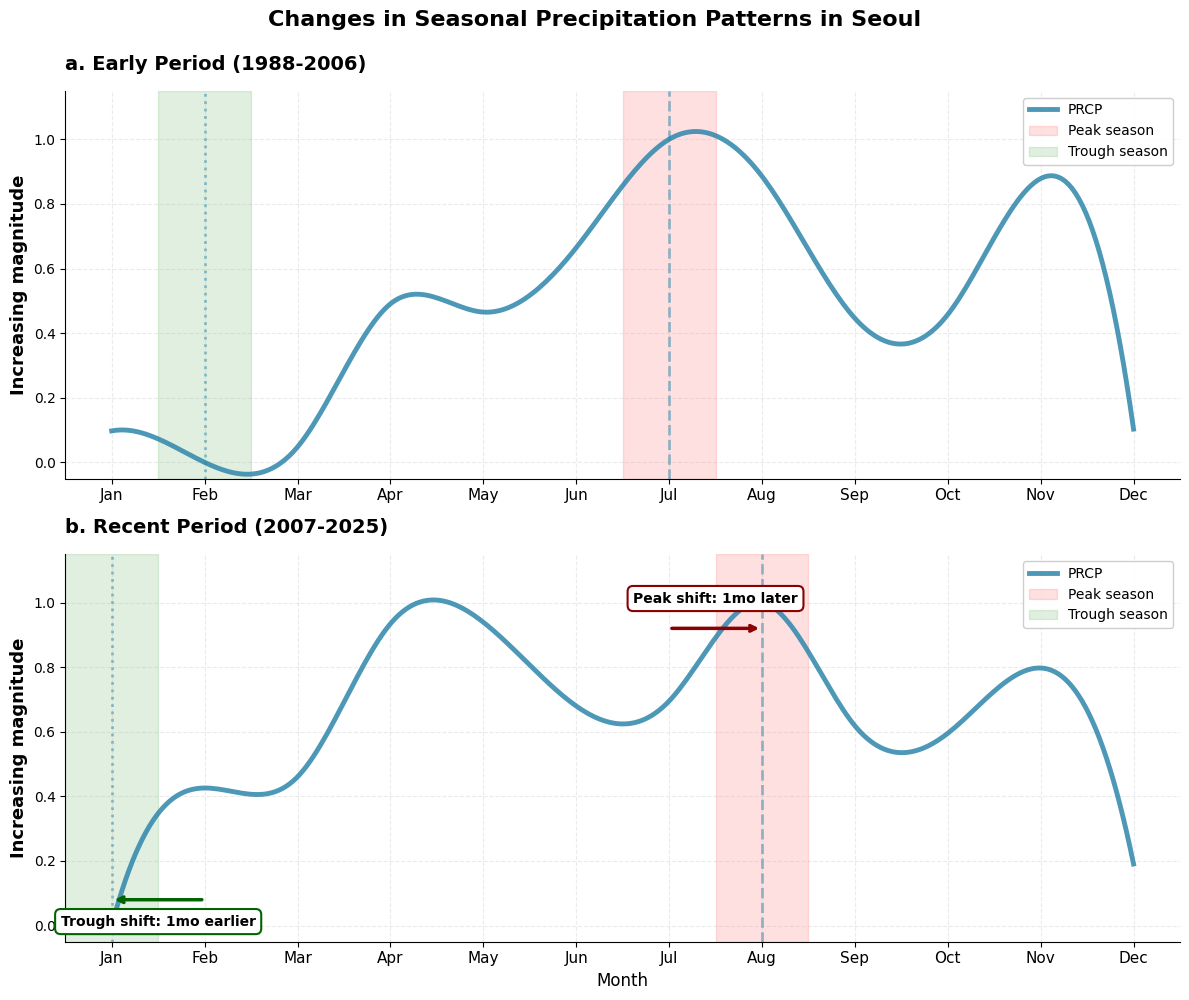

SEASONAL PATTERN SHIFT ANALYSIS: PRECIPITATION

Time periods:
  Early: 1988-2006
  Recent: 2007-2025

PRCP:
----------------------------------------------------------------------
  Peak concentration:
    Early:  Jul (month 7)
    Recent: Aug (month 8)
    Shift:  +1 months
  Trough concentration:
    Early:  Feb (month 2)
    Recent: Jan (month 1)
    Shift:  -1 months



In [46]:
# Prepare data for precipitation
pollutants_to_plot = {
    'PRCP': precip_df
}

# Function to prepare dataframe and remove outliers
def prepare_pollutant_data(series, pollutant_name):
    df = series.copy()
    
    # Convert DATE to datetime and set as index if not already
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.set_index('DATE', inplace=True)
    
    # Add month and year columns for grouping
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    # Remove outliers
    Q1 = df[pollutant_name].quantile(0.25)
    Q3 = df[pollutant_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[pollutant_name] >= lower_bound) & (df[pollutant_name] <= upper_bound)].copy()
    return df_filtered

# Prepare pollutant dataframes
pollutant_dfs = {}
for name, series in pollutants_to_plot.items():
    pollutant_dfs[name] = prepare_pollutant_data(series, name)

# Split data into time periods
all_years = sorted(pollutant_dfs['PRCP']['Year'].unique())
n_years = len(all_years)
split_point = n_years // 2

early_years = all_years[:split_point]
recent_years = all_years[split_point:]

# Create figure with two subplots (early and recent)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# Define color for precipitation (different from PM colors)
colors = {
    'PRCP': '#2E86AB'  # Blue
}

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Store peak and trough information for annotations
peak_info = {'early': {}, 'recent': {}}
trough_info = {'early': {}, 'recent': {}}

# Plot 1: Early period
ax = axes[0]
for pollutant_name, df in pollutant_dfs.items():
    early_data = df[df['Year'].isin(early_years)]
    early_monthly = early_data.groupby('Month')[pollutant_name].mean()
    
    # Normalize to 0-1 scale
    early_normalized = (early_monthly - early_monthly.min()) / (early_monthly.max() - early_monthly.min())
    
    # Create smooth curves
    months = np.array(range(1, 13))
    months_smooth = np.linspace(1, 12, 300)
    
    spline_early = make_interp_spline(months, early_normalized.values, k=3)
    early_smooth = spline_early(months_smooth)
    
    # Plot
    ax.plot(months_smooth, early_smooth, linewidth=3.5, 
            color=colors[pollutant_name], label=pollutant_name, alpha=0.85)
    
    # Store peak and trough information
    early_peak_month = early_monthly.idxmax()
    early_trough_month = early_monthly.idxmin()
    peak_info['early'][pollutant_name] = early_peak_month
    trough_info['early'][pollutant_name] = early_trough_month
    
    # Add vertical lines at peak and trough
    ax.axvline(early_peak_month, color=colors[pollutant_name], 
               linestyle='--', linewidth=2, alpha=0.5)
    ax.axvline(early_trough_month, color=colors[pollutant_name], 
               linestyle=':', linewidth=2, alpha=0.5)

# Add shaded regions for peak and trough seasons
peaks_early = list(peak_info['early'].values())
troughs_early = list(trough_info['early'].values())

if len(set(peaks_early)) > 1:
    ax.axvspan(min(peaks_early) - 0.5, max(peaks_early) + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season range')
else:
    ax.axvspan(peaks_early[0] - 0.5, peaks_early[0] + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season')

if len(set(troughs_early)) > 1:
    ax.axvspan(min(troughs_early) - 0.5, max(troughs_early) + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season range')
else:
    ax.axvspan(troughs_early[0] - 0.5, troughs_early[0] + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season')

# Formatting for early period plot
fig.suptitle('Changes in Seasonal Precipitation Patterns in Seoul', fontsize=16, fontweight='bold', y=0.995)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=11)
ax.set_ylabel('Increasing magnitude', fontsize=13, fontweight='bold')
ax.set_title(f'a. Early Period ({early_years[0]}-{early_years[-1]})', 
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0.5, 12.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.25, linestyle='--')

# Plot 2: Recent period
ax = axes[1]
for pollutant_name, df in pollutant_dfs.items():
    recent_data = df[df['Year'].isin(recent_years)]
    recent_monthly = recent_data.groupby('Month')[pollutant_name].mean()
    
    # Normalize to 0-1 scale
    recent_normalized = (recent_monthly - recent_monthly.min()) / (recent_monthly.max() - recent_monthly.min())
    
    # Create smooth curves
    months = np.array(range(1, 13))
    months_smooth = np.linspace(1, 12, 300)
    
    spline_recent = make_interp_spline(months, recent_normalized.values, k=3)
    recent_smooth = spline_recent(months_smooth)
    
    # Plot
    ax.plot(months_smooth, recent_smooth, linewidth=3.5, 
            color=colors[pollutant_name], label=pollutant_name, alpha=0.85)
    
    # Store peak and trough information
    recent_peak_month = recent_monthly.idxmax()
    recent_trough_month = recent_monthly.idxmin()
    peak_info['recent'][pollutant_name] = recent_peak_month
    trough_info['recent'][pollutant_name] = recent_trough_month
    
    # Add vertical lines at peak and trough
    ax.axvline(recent_peak_month, color=colors[pollutant_name], 
               linestyle='--', linewidth=2, alpha=0.5)
    ax.axvline(recent_trough_month, color=colors[pollutant_name], 
               linestyle=':', linewidth=2, alpha=0.5)

# Add shaded regions
peaks_recent = list(peak_info['recent'].values())
troughs_recent = list(trough_info['recent'].values())

if len(set(peaks_recent)) > 1:
    ax.axvspan(min(peaks_recent) - 0.5, max(peaks_recent) + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season range')
else:
    ax.axvspan(peaks_recent[0] - 0.5, peaks_recent[0] + 0.5, 
               alpha=0.12, color='red', zorder=0, label='Peak season')

if len(set(troughs_recent)) > 1:
    ax.axvspan(min(troughs_recent) - 0.5, max(troughs_recent) + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season range')
else:
    ax.axvspan(troughs_recent[0] - 0.5, troughs_recent[0] + 0.5, 
               alpha=0.12, color='green', zorder=0, label='Trough season')

# Add arrows showing shifts for both peak and trough
avg_early_peak = np.mean(peaks_early)
avg_recent_peak = np.mean(peaks_recent)
avg_early_trough = np.mean(troughs_early)
avg_recent_trough = np.mean(troughs_recent)

# Peak shift arrow
if abs(avg_recent_peak - avg_early_peak) > 0.5:
    arrow_y_peak = 0.92
    ax.annotate('', xy=(avg_recent_peak, arrow_y_peak), 
                xytext=(avg_early_peak, arrow_y_peak),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='darkred'))
    
    shift_months = int(round(avg_recent_peak - avg_early_peak))
    shift_text = f'Peak shift: {abs(shift_months)}mo {"later" if shift_months > 0 else "earlier"}'
    ax.text((avg_early_peak + avg_recent_peak) / 2, arrow_y_peak + 0.08, 
            shift_text, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                     edgecolor='darkred', linewidth=1.5))

# Trough shift arrow
if abs(avg_recent_trough - avg_early_trough) > 0.5:
    arrow_y_trough = 0.08
    ax.annotate('', xy=(avg_recent_trough, arrow_y_trough), 
                xytext=(avg_early_trough, arrow_y_trough),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='darkgreen'))
    
    shift_months = int(round(avg_recent_trough - avg_early_trough))
    shift_text = f'Trough shift: {abs(shift_months)}mo {"later" if shift_months > 0 else "earlier"}'
    ax.text((avg_early_trough + avg_recent_trough) / 2, arrow_y_trough - 0.08, 
            shift_text, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                     edgecolor='darkgreen', linewidth=1.5))

# Formatting for recent period plot
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=11)
ax.set_ylabel('Increasing magnitude', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_title(f'b. Recent Period ({recent_years[0]}-{recent_years[-1]})', 
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0.5, 12.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

# Print statistical summary
print("="*70)
print("SEASONAL PATTERN SHIFT ANALYSIS: PRECIPITATION")
print("="*70)
print(f"\nTime periods:")
print(f"  Early: {early_years[0]}-{early_years[-1]}")
print(f"  Recent: {recent_years[0]}-{recent_years[-1]}")
print()

for pollutant_name, df in pollutant_dfs.items():
    print(f"{pollutant_name}:")
    print("-"*70)
    
    early_data = df[df['Year'].isin(early_years)]
    recent_data = df[df['Year'].isin(recent_years)]
    
    early_monthly = early_data.groupby('Month')[pollutant_name].mean()
    recent_monthly = recent_data.groupby('Month')[pollutant_name].mean()
    
    early_peak = early_monthly.idxmax()
    recent_peak = recent_monthly.idxmax()
    early_trough = early_monthly.idxmin()
    recent_trough = recent_monthly.idxmin()
    
    print(f"  Peak concentration:")
    print(f"    Early:  {month_names[early_peak-1]} (month {early_peak})")
    print(f"    Recent: {month_names[recent_peak-1]} (month {recent_peak})")
    print(f"    Shift:  {recent_peak - early_peak:+d} months")
    
    print(f"  Trough concentration:")
    print(f"    Early:  {month_names[early_trough-1]} (month {early_trough})")
    print(f"    Recent: {month_names[recent_trough-1]} (month {recent_trough})")
    print(f"    Shift:  {recent_trough - early_trough:+d} months")
    print()

print("="*70)